# Goal: Make Figure 5 for Egr1 paper: Egr1 binds differently in Males and Females.

In [1]:
import pycallingcards as cc
import pybedtools
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib import pyplot as plt
plt.rcParams['figure.dpi'] = 150

In [2]:
Male_Egr1 = cc.rd.read_qbed('/lts/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/output_and_analysis/insertions/TCGTG_Male_Egr1_22CNMGLT4_S249_L008_R1_001_map_sort_final_chrY_filtered.qbed')
Male_Egr1['group'] = 'Male_Egr1'
Male_Egr1
Male_WT = cc.rd.read_qbed('/lts/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/output_and_analysis/insertions/TCGTG_Male_WT_22CNMGLT4_S249_L008_R1_001_map_sort_final_chrY_filtered.qbed')
Male_WT['group'] = 'Male_WT'
Male_WT

,Chr,Start,End,Reads,Direction,Barcodes,group
0,chr1,3056740,3056744,1,+,TCGTG/CTCACGGTGC/GTCA,Male_WT
1,chr1,3056740,3056744,2,+,TCGTG/CTCACGGTGC/TTGG,Male_WT
2,chr1,3057564,3057568,1,-,TCGTG/CTCACGGTGC/GTCA,Male_WT
3,chr1,3058419,3058423,6,-,TCGTG/CTCACGGTGC/CTTC,Male_WT
4,chr1,3175815,3175819,1,+,TCGTG/CTCACGGTGC/GAAG,Male_WT
...,...,...,...,...,...,...,...
1907938,chrY,90808770,90808774,23,-,TCGTG/CTAGGTGGAC/CATG,Male_WT
1907939,chrY,90809800,90809804,1,-,TCGTG/CTAGGTGGAC/GTCA,Male_WT
1907940,chrY,90838013,90838017,4,+,TCGTG/CTAGGTGGAC/CATG,Male_WT
1907941,chrY,90840202,90840206,1,-,TCGTG/CTAGGTGGAC/TCAG,Male_WT


In [3]:
Female_Egr1 = cc.rd.read_qbed('/lts/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/output_and_analysis/insertions/TCGTG_Female_Egr1_22CNMGLT4_S249_L008_R1_001_map_sort_final_chrY_filtered.qbed')
Female_Egr1['group'] = 'Female_Egr1'
Female_Egr1
Female_WT = cc.rd.read_qbed('/lts/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/output_and_analysis/insertions/TCGTG_Female_WT_22CNMGLT4_S249_L008_R1_001_map_sort_final_chrY_filtered.qbed')
Female_WT['group'] = 'Female_WT'
Female_WT

,Chr,Start,End,Reads,Direction,Barcodes,group
0,chr1,3031511,3031515,6,-,TCGTG/TTGTCCAACT/GTCA,Female_WT
1,chr1,3055972,3055976,1,+,TCGTG/TTGTCCAACT/TTGG,Female_WT
2,chr1,3118633,3118637,54,+,TCGTG/TTGTCCAACT/TTGG,Female_WT
3,chr1,3137382,3137386,1,-,TCGTG/TTGTCCAACT/GTTG,Female_WT
4,chr1,3152722,3152726,2,-,TCGTG/TTGTCCAACT/TCGA,Female_WT
...,...,...,...,...,...,...,...
1499371,chrY,90792082,90792086,1,-,TCGTG/GTCGTGCAAC/CATG,Female_WT
1499372,chrY,90799217,90799221,4,-,TCGTG/GTCGTGCAAC/TTGG,Female_WT
1499373,chrY,90800602,90800606,1,-,TCGTG/GTCGTGCAAC/TTGG,Female_WT
1499374,chrY,90807631,90807635,1,-,TCGTG/GTCGTGCAAC/TTGG,Female_WT


In [4]:
# Load packages and set workind directory import os
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import seaborn as sns
from gseapy import enrichr
from textwrap import wrap

# Set output directory
figure_output_dir = '/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/testing_CC_forPaper'
#os.makedirs(figure_output_dir, exist_ok=True)

In [5]:
import os
os.getcwd()

'/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/testing_CC_forPaper'

Visualize some peaks

In [14]:
# Call Peaks separately
peak_data_Male = cc.pp.call_peaks(Male_Egr1, Male_WT, method = "MACCs", reference = "mm10", pvalue_cutoffbg = 0.005,
                             window_size = 300, step_size = 150, pvalue_cutoffTTAA = 0.001,
                             #lam_win_size = 1000000, pseudocounts = 0.1, record = True, save = "Egr1CC_peak_MaleEgr1_VS_MaleWT_MACC2_window1000_YchromFiltered_window300_p05_TTAAp001_091325.bed")
peak_data_Male

peak_data_Female = cc.pp.call_peaks(Female_Egr1, Female_WT, method = "MACCs", reference = "mm10", pvalue_cutoffbg = 0.05,
                             window_size = 300, step_size = 150, pvalue_cutoffTTAA = 0.001,
                             #lam_win_size = 1000000, pseudocounts = 0.1, record = True, save = "Egr1CC_peak_FemaleEgr1_VS_FemaleWT_MACC2_window1000_YchromFiltered_window300_p05_TTAAp001_091325.bed")
peak_data_Female

For the MACCs method with background, [expdata, background, reference, pvalue_cutoffbg, pvalue_cutoffTTAA, lam_win_size, window_size, step_size, extend, pseudocounts, test_method, min_insertions, record] would be utilized.


100%|██████████| 54/54 [38:13<00:00, 42.47s/it]   


For the MACCs method with background, [expdata, background, reference, pvalue_cutoffbg, pvalue_cutoffTTAA, lam_win_size, window_size, step_size, extend, pseudocounts, test_method, min_insertions, record] would be utilized.


100%|██████████| 53/53 [21:42<00:00, 24.57s/it]  


,Chr,Start,End,Center,Experiment Insertions,Background insertions,Reference Insertions,pvalue Reference,pvalue Background,Fraction Experiment,TPH Experiment,Fraction background,TPH background,TPH background subtracted,pvalue_adj Reference
0,chr1,4857269,4857866,4857663.0,22,18,4,0.000000e+00,0.033448,0.000019,1867.209176,0.000012,1200.499408,666.709768,0.000000e+00
1,chr1,4858460,4859024,4858781.0,45,40,7,0.000000e+00,0.021114,0.000038,3819.291496,0.000027,2667.776462,1151.515034,0.000000e+00
2,chr1,4859557,4860097,4859828.0,12,8,8,3.919087e-14,0.020709,0.000010,1018.477732,0.000005,533.555292,484.922440,4.743755e-11
3,chr1,6215285,6215688,6215485.0,10,8,2,1.251999e-12,0.002301,0.000008,848.731444,0.000005,533.555292,315.176151,1.312868e-09
4,chr1,6274010,6274413,6274210.0,5,5,1,3.218919e-07,0.040376,0.000004,424.365722,0.000003,333.472058,90.893664,1.695793e-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11767,chrX,169861134,169861537,169861334.0,8,4,4,3.064298e-10,0.000718,0.000007,678.985155,0.000003,266.777646,412.207509,2.482385e-07
11768,chrX,169881476,169881879,169881676.0,10,6,2,3.441691e-15,0.000991,0.000008,848.731444,0.000004,400.166469,448.564974,4.557115e-12
11769,chrX,169882972,169883467,169883172.0,10,10,8,1.646687e-10,0.032990,0.000008,848.731444,0.000007,666.944115,181.787328,1.377614e-07
11770,chrX,169884037,169884658,169884237.0,12,12,8,4.716227e-13,0.023849,0.000010,1018.477732,0.000008,800.332939,218.144794,5.157978e-10


# Now add CC limits to 20kb.

In [21]:
# 1) Get Nearest or 2nd Nearest CC peaks. (So both, but only keep unique genes in the list).

# Read in bed file so I don't have to rerun the code above everytime I open jupyterlab noteboook.
import pandas as pd
# Read BED file into a DataFrame
bed_file = "Egr1CC_peak_MaleEgr1_VS_MaleWT_MACC2_window1000_YchromFiltered_window300_p05.bed"
peak_data_Male = pd.read_csv(bed_file, sep='\t', header=None)
# Add column names (optional)
peak_data_Male.columns = ['Chr', 'Start', 'End', 'Center', 'Experiment Insertions', 'Background insertions', 'Reference Insertions', 'pvalue Reference', 'pvalue Background', 'Fraction Experiment', 'TPH Experiment', 'Fraction background', 'TPH background', 'TPH background subtracted', 'pvalue_adj Reference']
#print(peak_data_Male.head())
len(peak_data_Male)

# Read in bed file so I don't have to rerun the code above everytime I open jupyterlab noteboook.
import pandas as pd
# Read BED file into a DataFrame
bed_file = "Egr1CC_peak_FemaleEgr1_VS_FemaleWT_MACC2_window1000_YchromFiltered_window300_p05.bed"
peak_data_Female = pd.read_csv(bed_file, sep='\t', header=None)
# Add column names (optional)
peak_data_Female.columns = ['Chr', 'Start', 'End', 'Center', 'Experiment Insertions', 'Background insertions', 'Reference Insertions', 'pvalue Reference', 'pvalue Background', 'Fraction Experiment', 'TPH Experiment', 'Fraction background', 'TPH background', 'TPH background subtracted', 'pvalue_adj Reference']
#print(peak_data_Male.head())
len(peak_data_Female)

# Annotate
peak_annotation_Male = cc.pp.annotation(peak_data_Male, reference = "mm10", bedtools_path = '/ref/rmlab/software/pycallingcards/bin')
peak_annotation_Male = cc.pp.combine_annotation(peak_data_Male, peak_annotation_Male)
peak_annotation_Male
# Keep only peaks whose nearest gene is within 20kb
peak_annotation_Male_20000 = peak_annotation_Male[peak_annotation_Male['Distance1'].abs() <= 20000].reset_index(drop=True)
#peak_annotation_Male_100000 = peak_annotation_Male[peak_annotation_Male['Distance1'].abs() <= 100000].reset_index(drop=True)
peak_annotation_Male_20000.to_csv("Male_Egr1CC_peaks_20kbThreshhold_091125_111225.txt", sep="\t", index=False, header=True)
#peak_annotation_Male_100000.to_csv("Male_Egr1CC_peaks_100kbThreshhold_090825.txt", sep="\t", index=False, header=True)

peak_annotation_Female = cc.pp.annotation(peak_data_Female, reference = "mm10", bedtools_path = '/ref/rmlab/software/pycallingcards/bin')
peak_annotation_Female = cc.pp.combine_annotation(peak_data_Female, peak_annotation_Female)
peak_annotation_Female
peak_annotation_Female_20000 = peak_annotation_Female[peak_annotation_Female['Distance1'].abs() <= 20000].reset_index(drop=True)
#peak_annotation_Female_100000 = peak_annotation_Female[peak_annotation_Female['Distance1'].abs() <= 100000].reset_index(drop=True)
peak_annotation_Female_20000.to_csv("Female_Egr1CC_peaks_20kbThreshhold_091125_111225.txt", sep="\t", index=False, header=True)
#peak_annotation_Female_100000.to_csv("Female_Egr1CC_peaks_100kbThreshhold_090825.txt", sep="\t", index=False, header=True)



In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.
In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.


In [22]:
# genes to search for
genes_of_interest = ['Nrp1', 'Hmox1', 'Mast4', 'Ptk2b']

# rows where Gene Name1 contains any of those genes
matches = peak_annotation_Male_20000[peak_annotation_Male_20000['Gene Name1'].isin(genes_of_interest)]

print(matches)

        Chr      Start        End       Center  Experiment Insertions  \
2554  chr13  102880532  102880935  102880732.0                      7   
2555  chr13  102905960  102906363  102906160.0                     10   
2556  chr13  102989840  102990405  102990202.0                     11   
2557  chr13  103102595  103102998  103102795.0                      6   
2874  chr14   66257838   66258908   66258190.0                     56   
8435   chr8   75083077   75083498   75083295.0                      7   
8436   chr8   75083709   75084112   75083909.0                     17   
8437   chr8   75087726   75088129   75087926.0                      7   
8438   chr8   75093390   75093793   75093590.0                     12   
8669   chr8  128360037  128360896  128360312.0                     21   
8670   chr8  128378218  128378621  128378418.0                     31   
8671   chr8  128450301  128450887  128450618.0                     17   

      Background insertions  Reference Insertions 

In [23]:
# genes to search for
genes_of_interest = ['Nrp1', 'Hmox1', 'Mast4', 'Ptk2b']

# rows where Gene Name1 contains any of those genes
matches = peak_annotation_Female_20000[peak_annotation_Female_20000['Gene Name1'].isin(genes_of_interest)]

print(matches)

        Chr      Start        End       Center  Experiment Insertions  \
2496  chr13  102833687  102834304  102833887.0                      7   
2497  chr13  102865958  102866627  102866253.0                      7   
2498  chr13  102899110  102899513  102899310.0                     10   
2499  chr13  102905735  102906363  102906049.5                     14   
2500  chr13  103077796  103078275  103078017.0                     11   
2501  chr13  103097019  103097540  103097219.0                      5   
2502  chr13  103102595  103102998  103102795.0                      7   
8599   chr8   75083941   75084468   75084141.0                     36   
8600   chr8   75087726   75088129   75087926.0                     10   
8601   chr8   75094600   75095342   75094974.0                     12   
8851   chr8  128359717  128360120  128359917.0                     15   
8852   chr8  128378126  128378621  128378418.0                     25   
8853   chr8  128383293  128383978  128383684.0     

In [8]:
len(peak_data_Female)

11772

# Find Nrp1 cut offs

In [12]:
import pandas as pd

MACC2_COLS = ['Chr', 'Start', 'End', 'Center',
              'Experiment Insertions', 'Background insertions', 'Reference Insertions',
              'pvalue Reference', 'pvalue Background',
              'Fraction Experiment', 'TPH Experiment',
              'Fraction background', 'TPH background', 'TPH background subtracted',
              'pvalue_adj Reference']

def load_macc2_bed(path):
    """Read a MACC2 call_peaks BED, auto-detecting a header row."""
    with open(path) as fh:
        has_header = fh.readline().split('\t')[0].strip().lower() in ('chr', 'chrom', '#chr')
    df = pd.read_csv(path, sep='\t', header=0 if has_header else None)
    if not has_header:
        df.columns = MACC2_COLS[:df.shape[1]]
    return df

import os
d = "/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/testing_CC_forPaper"

MALE_BED   = "Egr1CC_peak_MaleEgr1_VS_MaleWT_MACC2_window300_step150_YchromFiltered_window300_p05_bg0.001_TTAAp0001_051826.bed"
FEMALE_BED = "Egr1CC_peak_FemaleEgr1_VS_FemaleWT_MACC2_window300_step150_YchromFiltered_window300_p05_bg0.001_TTAAp0001_051826.bed"

peak_data_Male   = load_macc2_bed(os.path.join(d, MALE_BED))
peak_data_Female = load_macc2_bed(os.path.join(d, FEMALE_BED))
print(f"Male peaks:   {len(peak_data_Male)}")
print(f"Female peaks: {len(peak_data_Female)}")
peak_annotation_Male = cc.pp.combine_annotation(
    peak_data_Male,
    cc.pp.annotation(peak_data_Male, reference="mm10",
                     bedtools_path='/ref/rmlab/software/pycallingcards/bin'))
peak_annotation_Female = cc.pp.combine_annotation(
    peak_data_Female,
    cc.pp.annotation(peak_data_Female, reference="mm10",
                     bedtools_path='/ref/rmlab/software/pycallingcards/bin'))

Male peaks:   3060
Female peaks: 4266
In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.
In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.


In [9]:


# ----------------------------------------------------------------------------
# find Nrp1 and report its p-values
# ----------------------------------------------------------------------------
def find_gene_pvalues(anno, gene, label):
    mask = anno.apply(
        lambda r: r.astype(str).str.contains(rf'\b{gene}\b',
                                             case=False, regex=True, na=False).any(),
        axis=1)
    hits = anno[mask].copy()
    print(f"\n=== {gene} peaks in {label}: {len(hits)} ===")
    if len(hits) == 0:
        print("   (none)")
        return hits
    cols = [c for c in ['Chr', 'Start', 'End', 'Gene Name1', 'Distance1',
                        'Experiment Insertions', 'Background insertions',
                        'pvalue Background', 'pvalue Reference', 'pvalue_adj Reference']
            if c in hits.columns]
    print(hits[cols].to_string(index=False))
    for pcol in ['pvalue Background', 'pvalue Reference', 'pvalue_adj Reference']:
        if pcol in hits.columns:
            worst = pd.to_numeric(hits[pcol], errors='coerce').max()
            print(f"   loosest '{pcol}' among {gene} peaks: {worst:.3e}"
                  f"  -> cutoff must be >= this to keep all {len(hits)}")
    return hits

#nrp1_male_all    = find_gene_pvalues(peak_annotation_Male,        'Nrp1', 'MALE - all peaks')
nrp1_male_20kb   = find_gene_pvalues(peak_annotation_Male_20000,   'Nrp1', 'MALE - within 20 kb')
#nrp1_female_all  = find_gene_pvalues(peak_annotation_Female,      'Nrp1', 'FEMALE - all peaks')
nrp1_female_20kb = find_gene_pvalues(peak_annotation_Female_20000, 'Nrp1', 'FEMALE - within 20 kb')


=== Nrp1 peaks in MALE - within 20 kb: 6 ===
 Chr     Start       End Gene Name1  Distance1  Experiment Insertions  Background insertions  pvalue Background  pvalue Reference  pvalue_adj Reference
chr8 128272716 128273119     Mir21c       5029                     21                      5           0.000002      0.000000e+00          0.000000e+00
chr8 128360037 128360896       Nrp1          0                     21                      6           0.000022      2.998712e-13          3.207168e-10
chr8 128378218 128378621       Nrp1          0                     31                     18           0.018437      0.000000e+00          0.000000e+00
chr8 128450301 128450887       Nrp1          0                     17                      8           0.019014      2.540190e-13          2.740174e-10
chr8 128671695 128672317      Itgb1      13337                     16                      9           0.044795      3.774758e-15          4.821385e-12
chr8 128703900 128704303      Itgb1       

### Not sure what to do with these p values yet. What if I check the combined peaks too? 

In [12]:
# 1) Get Nearest or 2nd Nearest CC peaks. (So both, but only keep unique genes in the list).

# Read in bed file so I don't have to rerun the code above everytime I open jupyterlab noteboook.
import pandas as pd
# Read BED file into a DataFrame
bed_file = "Egr1CC_peak_MaleandFemale_Egr1_VS_WT_MACC2_window300_step150_YchromFiltered_bg0.005_TTAAp001_originalparameters_051826.bed"
peak_data_combined = pd.read_csv(bed_file, sep='\t', header=None)
# Add column names (optional)
peak_data_combined.columns = ['Chr', 'Start', 'End', 'Center', 'Experiment Insertions', 'Background insertions', 'Reference Insertions', 'pvalue Reference', 'pvalue Background', 'Fraction Experiment', 'TPH Experiment', 'Fraction background', 'TPH background', 'TPH background subtracted', 'pvalue_adj Reference']
#print(peak_data_Male.head())
len(peak_data_combined)

# Annotate
peak_annotation_combined = cc.pp.annotation(peak_data_combined, reference = "mm10", bedtools_path = '/ref/rmlab/software/pycallingcards/bin')
peak_annotation_combined = cc.pp.combine_annotation(peak_data_combined, peak_annotation_combined)
peak_annotation_combined
# Keep only peaks whose nearest gene is within 20kb
peak_annotation_combined = peak_annotation_combined[peak_annotation_combined['Distance1'].abs() <= 20000].reset_index(drop=True)
#peak_annotation_Male_100000 = peak_annotation_Male[peak_annotation_Male['Distance1'].abs() <= 100000].reset_index(drop=True)
peak_annotation_combined.to_csv("MaleAndFemale_Egr1_VS_WT_MACC2_window300_step150_YchromFiltered_bg0.005_TTAAp001_originalparameters_051826.txt", sep="\t", index=False, header=True)
#peak_annotation_Male_100000.to_csv("Male_Egr1CC_peaks_100kbThreshhold_090825.txt", sep="\t", index=False, header=True)
peak_annotation_combined

In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.


,Chr,Start,End,Center,Experiment Insertions,Background insertions,Reference Insertions,pvalue Reference,pvalue Background,Fraction Experiment,...,TPH background subtracted,pvalue_adj Reference,Nearest Refseq1,Gene Name1,Direction1,Distance1,Nearest Refseq2,Gene Name2,Direction2,Distance2
0,chr1,4857463,4857866,4857663.0,39,20,2,0.000000e+00,4.233797e-06,0.000019,...,1063.718797,0.000000e+00,NM_011541,Tcea1,+,0,NM_001159751,Tcea1,+,462
1,chr1,4858460,4858863,4858660.0,65,51,5,0.000000e+00,2.271406e-03,0.000031,...,1052.036312,0.000000e+00,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-11726
2,chr1,4916025,4916592,4916389.0,6,2,5,1.099970e-06,3.154024e-03,0.000003,...,207.589235,7.246548e-04,NM_001290372,Rgs20,-,0,NM_011541,Tcea1,+,-18117
3,chr1,6215285,6215688,6215485.0,16,12,2,0.000000e+00,8.744928e-04,0.000008,...,281.560596,0.000000e+00,NM_009826,Rb1cc1,+,0,NM_001195732,Alkal1,+,143643
4,chr1,7089145,7089548,7089345.0,49,19,1,0.000000e+00,1.924072e-11,0.000024,...,1586.507809,0.000000e+00,NM_183028,Pcmtd1,+,0,NM_001244693,St18,+,-228206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7100,chrX,167049494,167050024,167049694.0,14,9,2,0.000000e+00,3.165949e-03,0.000007,...,307.567929,0.000000e+00,NM_001101606,Gm8817,-,13425,NM_021278,Tmsb4x,-,157070
7101,chrX,168545917,168546320,168546117.0,5,0,3,3.527281e-08,1.274899e-09,0.000002,...,240.993704,2.767639e-05,NM_001033330,Frmpd4,-,0,NM_010832,Msl3,-,106779
7102,chrX,169795043,169795446,169795243.0,8,2,2,4.222012e-11,1.764470e-05,0.000004,...,303.986717,4.339553e-08,NM_010797,Mid1,+,0,NR_003635,4933400A11Rik,-,-15409
7103,chrX,169882972,169883497,169883211.0,11,7,8,4.536955e-10,2.794099e-03,0.000005,...,244.574916,4.260910e-07,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,91546


In [13]:
peak_annotation_combined

,Chr,Start,End,Center,Experiment Insertions,Background insertions,Reference Insertions,pvalue Reference,pvalue Background,Fraction Experiment,...,TPH background subtracted,pvalue_adj Reference,Nearest Refseq1,Gene Name1,Direction1,Distance1,Nearest Refseq2,Gene Name2,Direction2,Distance2
0,chr1,4857463,4857866,4857663.0,39,20,2,0.000000e+00,4.233797e-06,0.000019,...,1063.718797,0.000000e+00,NM_011541,Tcea1,+,0,NM_001159751,Tcea1,+,462
1,chr1,4858460,4858863,4858660.0,65,51,5,0.000000e+00,2.271406e-03,0.000031,...,1052.036312,0.000000e+00,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-11726
2,chr1,4916025,4916592,4916389.0,6,2,5,1.099970e-06,3.154024e-03,0.000003,...,207.589235,7.246548e-04,NM_001290372,Rgs20,-,0,NM_011541,Tcea1,+,-18117
3,chr1,6215285,6215688,6215485.0,16,12,2,0.000000e+00,8.744928e-04,0.000008,...,281.560596,0.000000e+00,NM_009826,Rb1cc1,+,0,NM_001195732,Alkal1,+,143643
4,chr1,7089145,7089548,7089345.0,49,19,1,0.000000e+00,1.924072e-11,0.000024,...,1586.507809,0.000000e+00,NM_183028,Pcmtd1,+,0,NM_001244693,St18,+,-228206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7100,chrX,167049494,167050024,167049694.0,14,9,2,0.000000e+00,3.165949e-03,0.000007,...,307.567929,0.000000e+00,NM_001101606,Gm8817,-,13425,NM_021278,Tmsb4x,-,157070
7101,chrX,168545917,168546320,168546117.0,5,0,3,3.527281e-08,1.274899e-09,0.000002,...,240.993704,2.767639e-05,NM_001033330,Frmpd4,-,0,NM_010832,Msl3,-,106779
7102,chrX,169795043,169795446,169795243.0,8,2,2,4.222012e-11,1.764470e-05,0.000004,...,303.986717,4.339553e-08,NM_010797,Mid1,+,0,NR_003635,4933400A11Rik,-,-15409
7103,chrX,169882972,169883497,169883211.0,11,7,8,4.536955e-10,2.794099e-03,0.000005,...,244.574916,4.260910e-07,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,91546


In [39]:
Egr1 = cc.rd.combine_qbed([Male_Egr1, Female_Egr1])
Egr1
Egr1 = Egr1[Egr1['Reads'] > 2]
Egr1

,Chr,Start,End,Reads,Direction,Barcodes,group
4,chr1,3055563,3055567,4,+,TCGTG/GTTATCGGAT/TCGA,Female_Egr1
7,chr1,3056983,3056987,8,+,TCGTG/GACTTAATAC/GTCA,Female_Egr1
18,chr1,3143887,3143891,6,+,TCGTG/ATACTCTAGG/CTTC,Male_Egr1
32,chr1,3283874,3283878,7,+,TCGTG/CACAGCGCGT/CTTC,Female_Egr1
36,chr1,3321360,3321364,3,+,TCGTG/GACTTAATAC/GTCA,Female_Egr1
...,...,...,...,...,...,...,...
3266319,chrY,90834140,90834144,16,-,TCGTG/GCTACATGTG/CATG,Male_Egr1
3266320,chrY,90834826,90834830,3,+,TCGTG/CACAGCGCGT/CTGA,Female_Egr1
3266322,chrY,90835877,90835881,8,-,TCGTG/CACAGCGCGT/GAAG,Female_Egr1
3266326,chrY,90837734,90837738,22,-,TCGTG/GTTATCGGAT/CATG,Female_Egr1


In [40]:
WT = cc.rd.combine_qbed([Male_WT, Female_WT])
WT
WT = WT[WT['Reads'] > 2]
WT

,Chr,Start,End,Reads,Direction,Barcodes,group
1,chr1,3031511,3031515,6,-,TCGTG/TTGTCCAACT/GTCA,Female_WT
3,chr1,3031511,3031515,3,-,TCGTG/GTCGTGCAAC/TGGT,Female_WT
5,chr1,3048018,3048022,9,-,TCGTG/GTCGTGCAAC/CATG,Female_WT
13,chr1,3055972,3055976,4,+,TCGTG/CTAGGTGGAC/TCAG,Male_WT
21,chr1,3058419,3058423,6,-,TCGTG/CTCACGGTGC/CTTC,Male_WT
...,...,...,...,...,...,...,...
3407297,chrY,90836044,90836048,6,-,TCGTG/CGTTACACAG/CTGA,Male_WT
3407298,chrY,90836126,90836130,3,+,TCGTG/CGCTGGCTCT/TTGG,Female_WT
3407299,chrY,90838013,90838017,4,+,TCGTG/CTAGGTGGAC/CATG,Male_WT
3407300,chrY,90838096,90838100,3,+,TCGTG/TTGTCCAACT/CATG,Female_WT


100%|██████████| 21/21 [00:03<00:00,  6.04it/s]


AnnData object with n_obs × n_vars = 2 × 7105
    var: 'Chr', 'Start', 'End', 'Center', 'Experiment Insertions', 'Background insertions', 'Reference Insertions', 'pvalue Reference', 'pvalue Background', 'Fraction Experiment', 'TPH Experiment', 'Fraction background', 'TPH background', 'TPH background subtracted', 'pvalue_adj Reference', 'Nearest Refseq1', 'Gene Name1', 'Direction1', 'Distance1', 'Nearest Refseq2', 'Gene Name2', 'Direction2', 'Distance2'
Empty DataFrame
Columns: []
Index: [Female_Egr1, Male_Egr1]


100%|██████████| 2/2 [00:51<00:00, 25.81s/it]


Female-biased peaks: 226
Male-biased peaks:   217


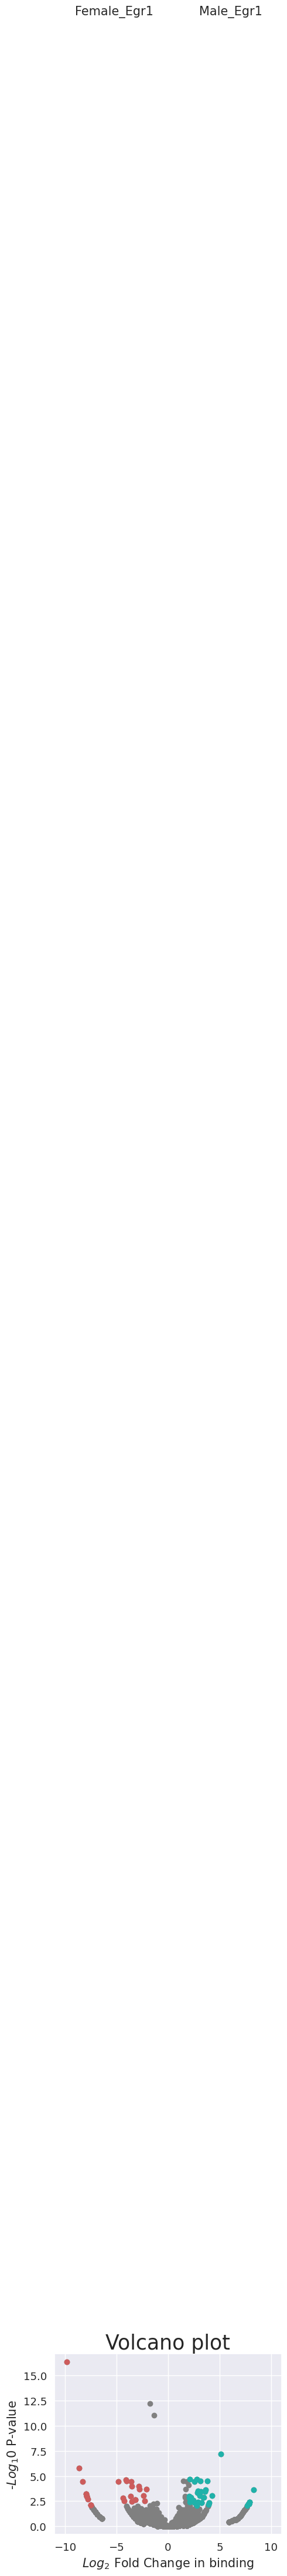

In [41]:
# =============================================================================
# CONTINUE FROM HERE (after peak_data_combined is created)
# =============================================================================
# Assumes:
#   - Egr1 = combined Male_Egr1 + Female_Egr1 qbed (filtered Reads > 2)
#   - WT = combined Male_WT + Female_WT qbed (filtered Reads > 2)
#   - Male_Egr1 has 'group' column = "Male_Egr1"
#   - Female_Egr1 has 'group' column = "Female_Egr1"
#   - peak_data_combined = joint peak calls (MACC2)


# =============================================================================
# 1. ANNOTATE PEAKS TO NEAREST GENES
# =============================================================================

# =============================================================================
# 1. ANNOTATE PEAKS TO NEAREST GENES
# =============================================================================
import pandas as pd


# =============================================================================
# 2. BUILD ANNDATA: GROUP × PEAK
# =============================================================================
# Counts Egr1 insertions per sex at each joint peak.

adata_cc = cc.pp.make_Anndata(
    Egr1,                                        # filtered combined Egr1 qbed
    peak_annotation_combined,
    ["Female_Egr1", "Male_Egr1"],
    key='group'
)
print(adata_cc)
print(adata_cc.obs)


# =============================================================================
# 3. DIFFERENTIAL PEAK ANALYSIS (Fisher's exact test)
# =============================================================================

cc.tl.rank_peak_groups(
    adata_cc,
    'Index',
    method='fisher_exact',
    key_added='fisher_exact'
)


# =============================================================================
# 4. VOLCANO PLOT
# =============================================================================

cc.pl.volcano_plot(
    adata_cc,
    pvalue_name='pvalues_adj',
    pvalue_cutoff=0.01,
    lfc_cutoff=2,
    figsize=(5, 4),
    labelright=(3, 250),
    labelleft=(-9, 250)
)


# =============================================================================
# 5. EXTRACT FEMALE-BIASED, MALE-BIASED, AND SHARED PEAKS
# =============================================================================

PVAL_CUT = 0.01
LFC_CUT  = 1     # try 1.5, 2, 3 — start at 2

female_biased = cc.tl.rank_peak_groups_df(
    adata_cc, key='fisher_exact',
    pval_cutoff=PVAL_CUT, logfc_min=LFC_CUT,
    group=['Female_Egr1']
)
male_biased = cc.tl.rank_peak_groups_df(
    adata_cc, key='fisher_exact',
    pval_cutoff=PVAL_CUT, logfc_min=LFC_CUT,
    group=['Male_Egr1']
)

print(f"Female-biased peaks: {len(female_biased)}")
print(f"Male-biased peaks:   {len(male_biased)}")


In [42]:
# =============================================================================
# 6. SHARED PEAKS + ANNOTATE BIASED & SHARED  ->  CSV
# =============================================================================
# Needs from above: peak_data_combined, peak_annotation_combined,
#                    female_biased, male_biased

# --- 6a. shared = all combined peaks MINUS the sex-biased ones ----------------
all_peaks_bed = peak_data_combined[['Chr', 'Start', 'End']].copy()
all_peaks_bed['name'] = (all_peaks_bed['Chr'].astype(str) + '_' +
                         all_peaks_bed['Start'].astype(int).astype(str) + '_' +
                         all_peaks_bed['End'].astype(int).astype(str))
biased_names = set(female_biased['names']) | set(male_biased['names'])
shared_bed = all_peaks_bed[~all_peaks_bed['name'].isin(biased_names)][['Chr', 'Start', 'End']]
print(f"Female-biased: {len(female_biased)} | Male-biased: {len(male_biased)} "
      f"| Shared: {len(shared_bed)}")

# --- 6b. matching key on the annotated combined table -------------------------
peak_annotation_combined['name'] = (
    peak_annotation_combined['Chr'].astype(str) + '_' +
    peak_annotation_combined['Start'].astype(int).astype(str) + '_' +
    peak_annotation_combined['End'].astype(int).astype(str))

# --- 6c. join Fisher DE stats with gene annotation ----------------------------
def annotate_de(de_df, label):
    merged = de_df.merge(peak_annotation_combined,
                         left_on='names', right_on='name',
                         how='left', suffixes=('', '_anno'))
    miss = merged['name'].isna().sum()
    if miss:
        print(f"  WARNING [{label}]: {miss} peaks unmatched -- check name formatting")
    return merged

female_annotated = annotate_de(female_biased, 'female')
male_annotated   = annotate_de(male_biased,   'male')

# --- 6d. shared peaks have no DE stats -- pull the annotation rows directly ----
shared_keys = (shared_bed['Chr'].astype(str) + '_' +
               shared_bed['Start'].astype(int).astype(str) + '_' +
               shared_bed['End'].astype(int).astype(str))
shared_annotated = peak_annotation_combined[
    peak_annotation_combined['name'].isin(set(shared_keys))].copy()

# --- 6e. save -----------------------------------------------------------------
female_annotated.to_csv('Egr1_female_biased_peaks_combinedcall_annotated_logfc1.csv', index=False)
male_annotated.to_csv(  'Egr1_male_biased_peaks_combinedcall_annotated_logfc1.csv',   index=False)
shared_annotated.to_csv('Egr1_shared_peaks_combinedcall_annotated_logfc1.csv',        index=False)
print(f"\nFemale-biased annotated: {len(female_annotated)} peaks")
print(f"Male-biased annotated:   {len(male_annotated)} peaks")
print(f"Shared annotated:        {len(shared_annotated)} peaks")
print("Saved 3 annotated CSVs.")

Female-biased: 226 | Male-biased: 217 | Shared: 8257

Female-biased annotated: 226 peaks
Male-biased annotated:   217 peaks
Shared annotated:        6662 peaks
Saved 3 annotated CSVs.


## Add RNAseq info to this

In [68]:
# =============================================================================
# 7. LABEL EACH SET, COMBINE, OVERLAP WITH gRNA3-vs-Neg1 RNAseq (both sexes)
# =============================================================================
import glob

# --- 7a. label each peak set and combine -------------------------------------
female_annotated = female_annotated.assign(category='female_biased')
male_annotated   = male_annotated.assign(category='male_biased')
shared_annotated = shared_annotated.assign(category='shared')

# =============================================================================
# 7. COMBINED PEAKS whose NEAREST GENE is DE in the Egr1 knockdown (per sex)
# =============================================================================
# Inputs from section 6: female_annotated, male_annotated, shared_annotated

# --- 7a. label + combine the three peak sets ---------------------------------
combined = pd.concat([
    female_annotated.assign(category='female_biased'),
    male_annotated.assign(category='male_biased'),
    shared_annotated.assign(category='shared'),
], ignore_index=True)
print(f"Combined peaks: {len(combined)}")

# --- 7b. load the two FULL RNAseq DE tables ----------------------------------
RNA_DIR = ("/lts/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/"
           "101524_Egr1CC_analysis/pycallingcards/R_work")
rna_f = pd.read_csv(f"{RNA_DIR}/Female_Egr1KDg3_vs_Female_NoTreatg1_DE_vst_filtered_091625.txt", sep='\t')
rna_m = pd.read_csv(f"{RNA_DIR}/Male_Egr1KDg3_vs_Male_NoTreatg1_DE_vst_filtered_091625.txt", sep='\t')

GENE_COL_RNA  = 'SYMBOL'        # gene-symbol column in the RNAseq tables
GENE_COL_PEAK = 'Gene Name1'    # nearest-gene column in the annotated peaks

# --- 7c. pull the DE gene set for each sex -----------------------------------
LFC_CUT, P_CUT = 0.5, 0.05      # "DE" = |log2FC| >= 0.5 and pvalue <= 0.05

def de_genes(rna, tag):
    de = rna[(rna['pvalue'] <= P_CUT) &
             (rna['log2FoldChange'].abs() >= LFC_CUT)].copy()
    de = de[[GENE_COL_RNA, 'log2FoldChange', 'pvalue', 'padj']]
    de.columns = ['gene', f'log2FC_{tag}', f'pvalue_{tag}', f'padj_{tag}']
    return (de.dropna(subset=['gene'])
              .sort_values(f'pvalue_{tag}')
              .drop_duplicates('gene'))

de_m = de_genes(rna_m, 'maleKD')
de_f = de_genes(rna_f, 'femaleKD')
print(f"DE genes -- male KD: {len(de_m)} | female KD: {len(de_f)}")

# =============================================================================
# 8. FULL DE GENE LIST per sex -- labeled with significance + peak category
# =============================================================================
# Inputs: combined (labeled peaks from 7a), rna_m, rna_f

LFC_CUT, P_CUT = 0.5, 0.05

# --- 8a. gene -> CC peak category(ies) ---------------------------------------
# A gene can be the nearest gene of several peaks; collect all their categories.
peaks_g = combined.dropna(subset=['Gene Name1'])
gene_cat = (peaks_g.groupby('Gene Name1')['category']
            .agg(lambda s: ';'.join(sorted(set(s))))
            .reset_index()
            .rename(columns={'Gene Name1': 'gene', 'category': 'peak_category'}))
gene_cat['n_peaks_near_gene'] = (peaks_g.groupby('Gene Name1').size()
                                 .reindex(gene_cat['gene']).values)

# --- 8b. label one sex's FULL gene list --------------------------------------
def labeled_gene_list(rna):
    def status(l, p):
        if pd.isna(l) or pd.isna(p) or p > P_CUT or abs(l) < LFC_CUT:
            return 'ns'
        return 'up' if l > 0 else 'down'
    t = rna.copy()
    t['DE_status'] = [status(l, p) for l, p in zip(t['log2FoldChange'], t['pvalue'])]
    t = t.merge(gene_cat, how='left', left_on='SYMBOL', right_on='gene').drop(columns='gene')
    t['peak_category']     = t['peak_category'].fillna('no_peak')
    t['n_peaks_near_gene'] = t['n_peaks_near_gene'].fillna(0).astype(int)
    return t

genes_male   = labeled_gene_list(rna_m)
genes_female = labeled_gene_list(rna_f)

# --- 8c. save ----------------------------------------------------------------
genes_male.to_csv('Egr1_maleKD_DEgenes_labeled_with_peakcategory.csv', index=False)
genes_female.to_csv('Egr1_femaleKD_DEgenes_labeled_with_peakcategory.csv', index=False)

print(f"Male KD:   {len(genes_male)} genes ({(genes_male['DE_status']!='ns').sum()} significant)")
print(f"Female KD: {len(genes_female)} genes ({(genes_female['DE_status']!='ns').sum()} significant)")
print("\nMale KD -- significant genes by peak category:")
print(genes_male[genes_male['DE_status']!='ns'].groupby('peak_category').size())
print("\nFemale KD -- significant genes by peak category:")
print(genes_female[genes_female['DE_status']!='ns'].groupby('peak_category').size())

Combined peaks: 7105
DE genes -- male KD: 577 | female KD: 714
Male KD:   18180 genes (579 significant)
Female KD: 18180 genes (720 significant)

Male KD -- significant genes by peak category:
peak_category
female_biased             4
female_biased;shared      8
male_biased               4
male_biased;shared        6
no_peak                 367
shared                  190
dtype: int64

Female KD -- significant genes by peak category:
peak_category
female_biased             6
female_biased;shared     10
male_biased               3
male_biased;shared        7
no_peak                 490
shared                  204
dtype: int64


In [73]:
# --- 7d. overlap of each DE gene set with the annotated peaks ----------------
import os

# >>> the annotated-peaks table you pasted at the top.
#     change `peaks` to whatever variable you actually loaded it into <
peaks_df = combined.copy()

OUT_DIR = RNA_DIR                       # where the overlap files get written
os.makedirs(OUT_DIR, exist_ok=True)

# case-insensitive gene key so 'Egr1' / 'EGR1' still match between tables
peaks_df['_key'] = peaks_df[GENE_COL_PEAK].astype(str).str.strip().str.upper()

def overlap_de_with_peaks(de, tag):
    de = de.copy()
    de['_key'] = de['gene'].astype(str).str.strip().str.upper()

    # inner merge -> keeps only peaks whose nearest gene (Gene Name1) is DE.
    # one row per PEAK; a DE gene near several peaks appears on several rows.
    merged = peaks_df.merge(de, on='_key', how='inner').drop(columns='_key')

    # most useful columns first; everything else trails after
    front = ['name', 'category', GENE_COL_PEAK, 'Direction1', 'Distance1',
             'Chr', 'Start', 'logfoldchanges', 'pvalues_adj',
             'gene', f'log2FC_{tag}', f'pvalue_{tag}', f'padj_{tag}']
    front = [c for c in front if c in merged.columns]
    merged = merged[front + [c for c in merged.columns if c not in front]]

    out = f"{OUT_DIR}/DE_{tag}_overlap_peaks.csv"
    merged.to_csv(out, index=False)

    n_de_total = de['gene'].nunique()
    n_de_hit   = merged['gene'].nunique()
    print(f"\n=== {tag} ===")
    print(f"DE genes total            : {n_de_total}")
    print(f"DE genes overlapping peaks: {n_de_hit}  "
          f"({n_de_total - n_de_hit} DE genes have no peak)")
    print(f"overlapping peaks         : {len(merged)}")
    print("peaks per category:")
    print(merged['category'].value_counts().to_string())
    print(f"saved -> {out}")
    return merged

ov_m = overlap_de_with_peaks(de_m, 'maleKD')
ov_f = overlap_de_with_peaks(de_f, 'femaleKD')

# side-by-side category summary
summary = (pd.concat([ov_m['category'].value_counts().rename('maleKD'),
                      ov_f['category'].value_counts().rename('femaleKD')],
                     axis=1).fillna(0).astype(int))
print("\n=== overlapping peaks by category ===")
print(summary)

OSError: [Errno 30] Read-only file system: '/lts/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/DE_maleKD_overlap_peaks.csv'

In [67]:
de_m

,gene,log2FC_maleKD,pvalue_maleKD,padj_maleKD
7576,Egr1,-4.284277,3.695480e-172,4.109744e-168
12786,Spp1,-0.816584,1.171639e-118,6.514897e-115
17647,Timp1,-0.866068,2.368989e-104,8.781842e-101
16869,Crabp1,1.010678,2.534520e-78,7.046600e-75
8340,Scd2,1.086482,8.305731e-74,1.847361e-70
...,...,...,...,...
12247,2310074N15Rik,-1.747632,4.922498e-02,NaN
2908,Mmp28,1.778570,4.924746e-02,NaN
2112,Sfi1,0.678533,4.925980e-02,2.409051e-01
17194,Slc9a9,1.479605,4.955523e-02,2.416062e-01


In [57]:
# --- 7b. load the two FULL RNAseq DE tables ----------------------------------
RNA_DIR = ("/lts/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/"
           "101524_Egr1CC_analysis/pycallingcards/R_work")
FEMALE_RNA = f"{RNA_DIR}/Female_Egr1KDg3_vs_Female_NoTreatg1_DE_vst_filtered_091625.txt"
MALE_RNA   = f"{RNA_DIR}/Male_Egr1KDg3_vs_Male_NoTreatg1_DE_vst_filtered_091625.txt"
# ^ the FULL DE tables -- NOT the *_common_DEGs_*.txt subsets

rna_f = pd.read_csv(FEMALE_RNA, sep='\t')
rna_m = pd.read_csv(MALE_RNA,   sep='\t')
print(f"Female RNAseq: {len(rna_f)} genes | Male RNAseq: {len(rna_m)} genes")

GENE_COL_RNA  = 'SYMBOL'        # gene-symbol column in the RNAseq tables
GENE_COL_PEAK = 'Gene Name1'    # nearest-gene column in the annotated peaks

# --- 7c. merge RNAseq log2FC / pvalue onto each peak's nearest gene ----------
def rna_slim(rna, tag):
    out = rna[[GENE_COL_RNA, 'log2FoldChange', 'pvalue']].copy()
    out.columns = ['gene', f'log2FC_{tag}', f'pvalue_{tag}']
    return (out.dropna(subset=['gene'])
               .sort_values(f'pvalue_{tag}')
               .drop_duplicates('gene'))

combined = (combined
            .merge(rna_slim(rna_f, 'female_KD'), how='left',
                   left_on=GENE_COL_PEAK, right_on='gene').drop(columns='gene')
            .merge(rna_slim(rna_m, 'male_KD'), how='left',
                   left_on=GENE_COL_PEAK, right_on='gene').drop(columns='gene'))

Female RNAseq: 18180 genes | Male RNAseq: 18180 genes


In [29]:
# locate Nrp1 in the annotated combined peaks
gmask = peak_annotation_combined.apply(
    lambda r: r.astype(str).str.contains(r'\bNrp1\b', case=False, regex=True, na=False).any(),
    axis=1)
nrp1_anno = peak_annotation_combined[gmask].copy()
nrp1_anno['name'] = (nrp1_anno['Chr'].astype(str) + '_' +
                     nrp1_anno['Start'].astype(int).astype(str) + '_' +
                     nrp1_anno['End'].astype(int).astype(str))

# full Fisher stats, no cutoff
all_stats = cc.tl.rank_peak_groups_df(adata_cc, key='fisher_exact',
                                      pval_cutoff=1.0, logfc_min=0.0, group=['Male_Egr1'])
male_set, fem_set = set(male_biased['names']), set(female_biased['names'])

rep = nrp1_anno[['Chr','Start','End','name']].merge(
    all_stats[['names','logfoldchanges','pvalues','pvalues_adj']],
    left_on='name', right_on='names', how='left')
for _, r in rep.iterrows():
    call = ("MALE-biased" if r['name'] in male_set else
            "FEMALE-biased" if r['name'] in fem_set else "shared / not significant")
    print(f"{r['name']}: logFC={r['logfoldchanges']:+.2f}  "
          f"p={r['pvalues']:.2e}  p_adj={r['pvalues_adj']:.2e}  -> {call}")

print(adata_cc.obs)   # check male vs female TOTAL insertions

chr8_128272716_128273119: logFC=+nan  p=nan  p_adj=nan  -> shared / not significant
chr8_128359717_128360708: logFC=+nan  p=nan  p_adj=nan  -> shared / not significant
chr8_128378126_128378621: logFC=+nan  p=nan  p_adj=nan  -> shared / not significant
chr8_128450301_128450887: logFC=+nan  p=nan  p_adj=nan  -> shared / not significant
chr8_128703329_128703846: logFC=+nan  p=nan  p_adj=nan  -> shared / not significant
Empty DataFrame
Columns: []
Index: [Female_Egr1, Male_Egr1]


# look at some of these peaks

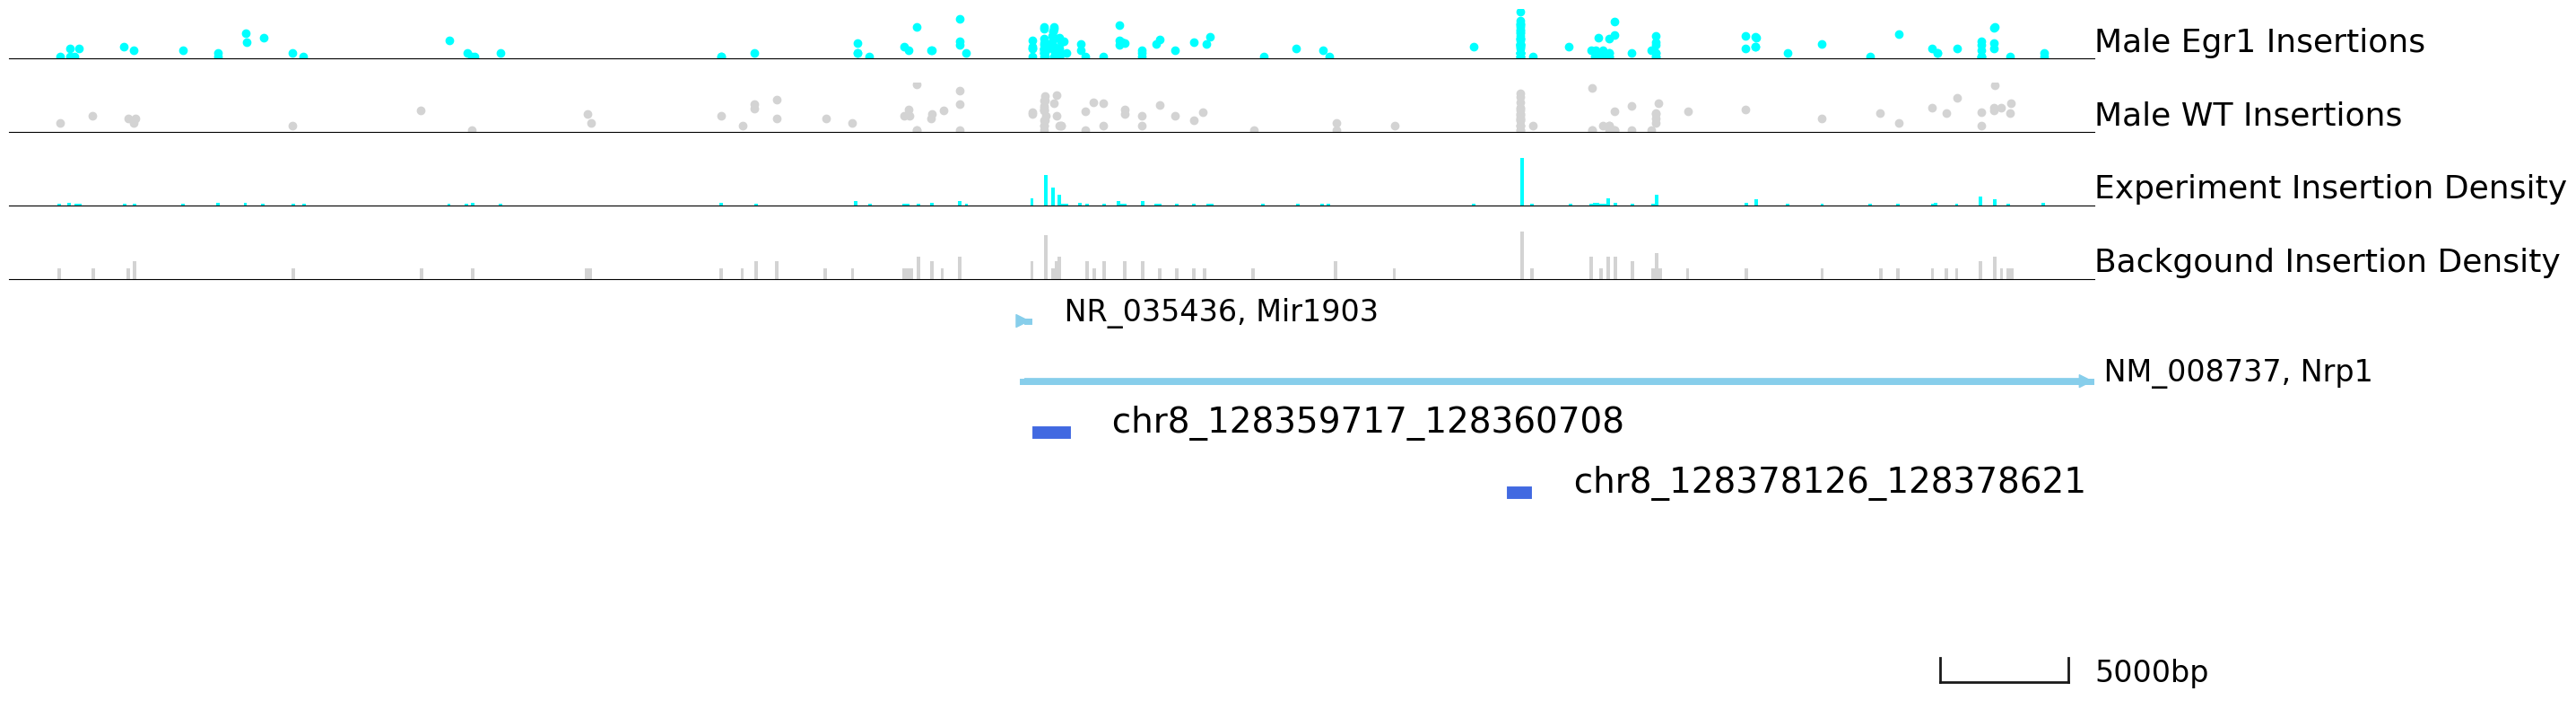

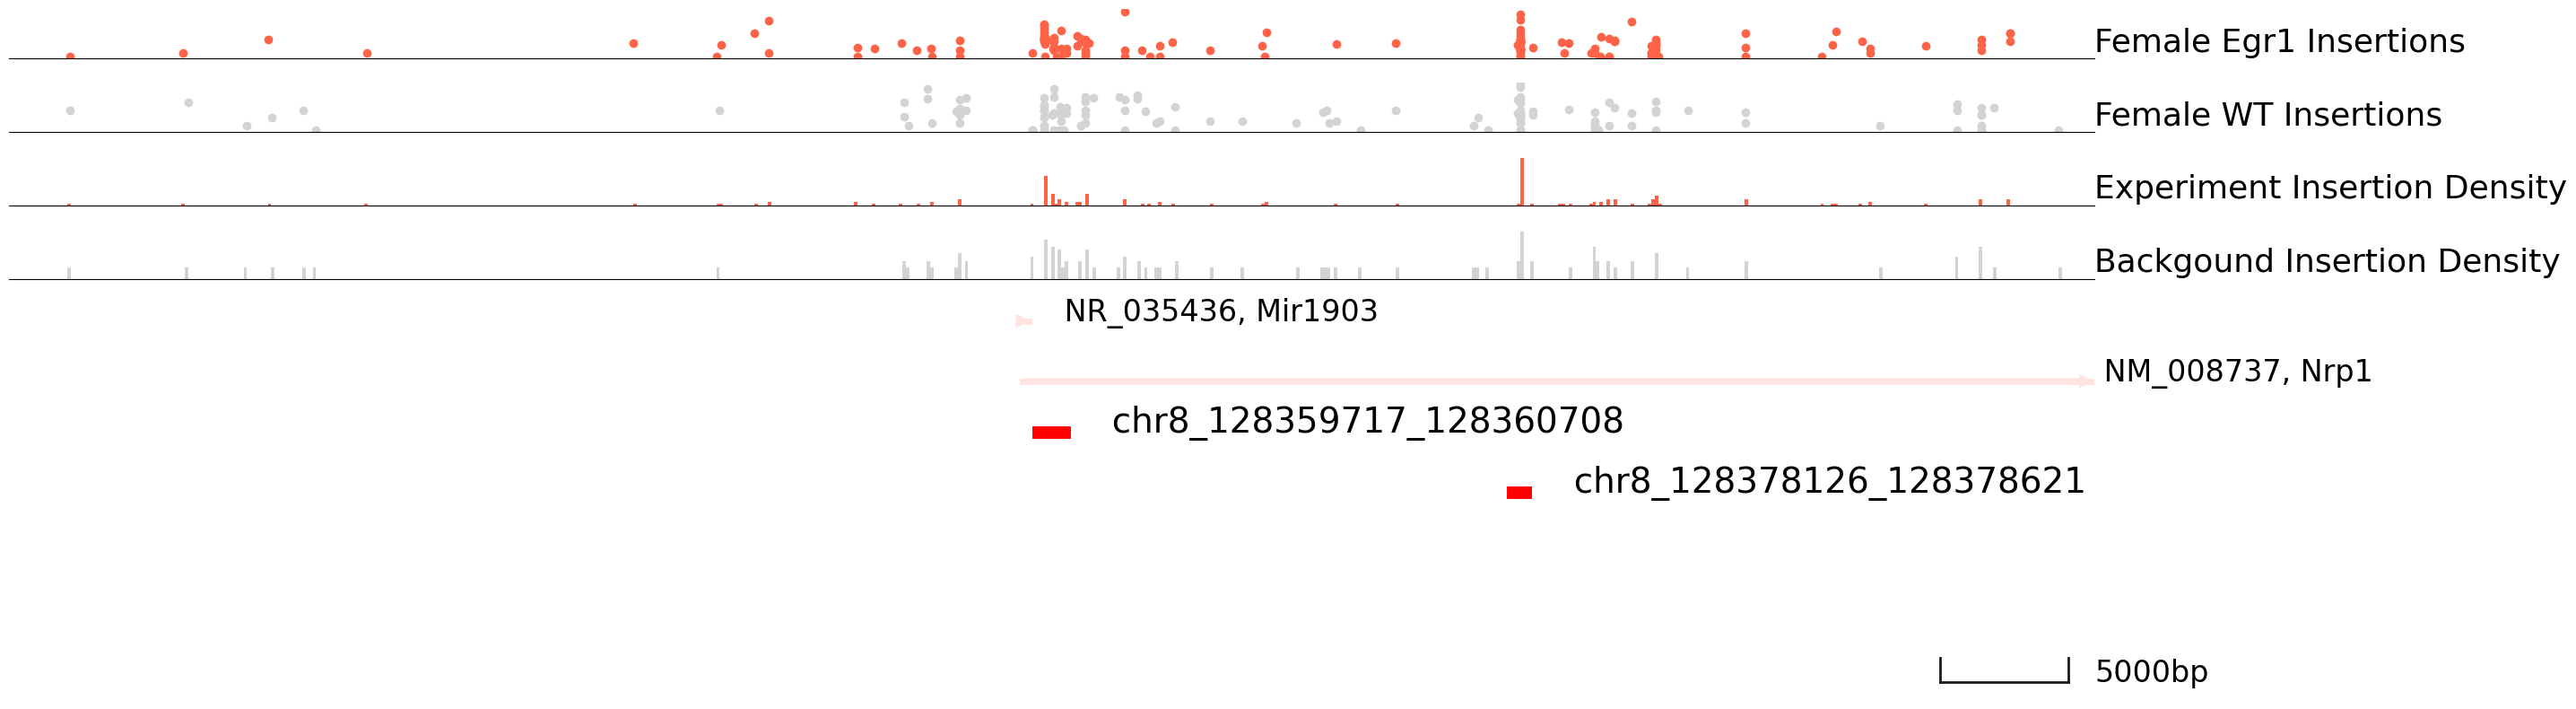

In [30]:
cc.pl.draw_area("chr8",128359717,128360708,40000, peak_annotation_combined, Male_Egr1, "mm10", Male_WT, font_size=2,
                name = "Male_Egr1", key = "Index", insertionkey = "group", figsize = (30,10), plotsize = [1,1,4],
                name_insertion1 = 'Male Egr1 Insertions', 
                name_insertion2 = 'Male WT Insertions', 
                peak_line = 3, bins = 600, example_length = 5000, color = "blue")#, title = "Male Egr1", save = 'Male_Egr1_WT_tracks_Zic4.pdf')
cc.pl.draw_area("chr8",128359717,128360708,40000, peak_annotation_combined, Female_Egr1, "mm10", Female_WT, font_size=2,
                name = "Female_Egr1", key = "Index", insertionkey = "group", figsize = (30,10), plotsize = [1,1,4],
                name_insertion1 = 'Female Egr1 Insertions', 
                name_insertion2 = 'Female WT Insertions', 
                peak_line = 3, bins = 600, example_length = 5000)#, title = "Female Egr1", save = 'Female_Egr1_WT_tracks_Zic4.pdf')


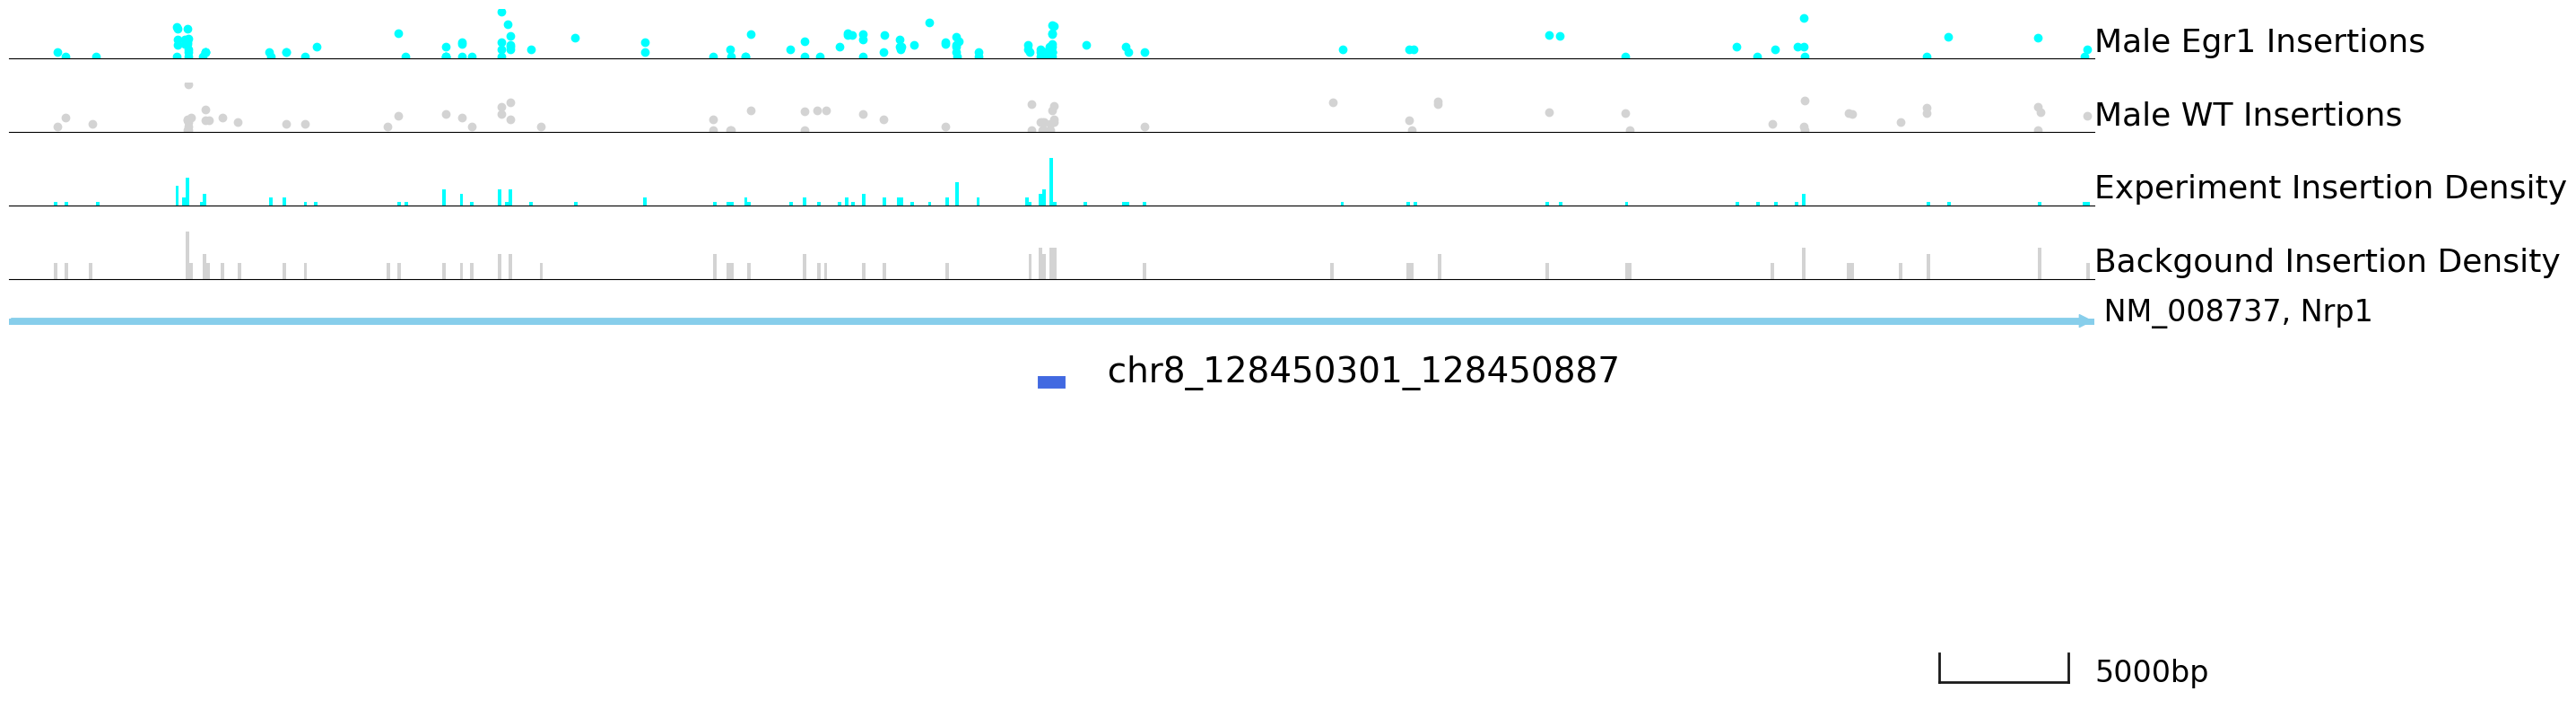

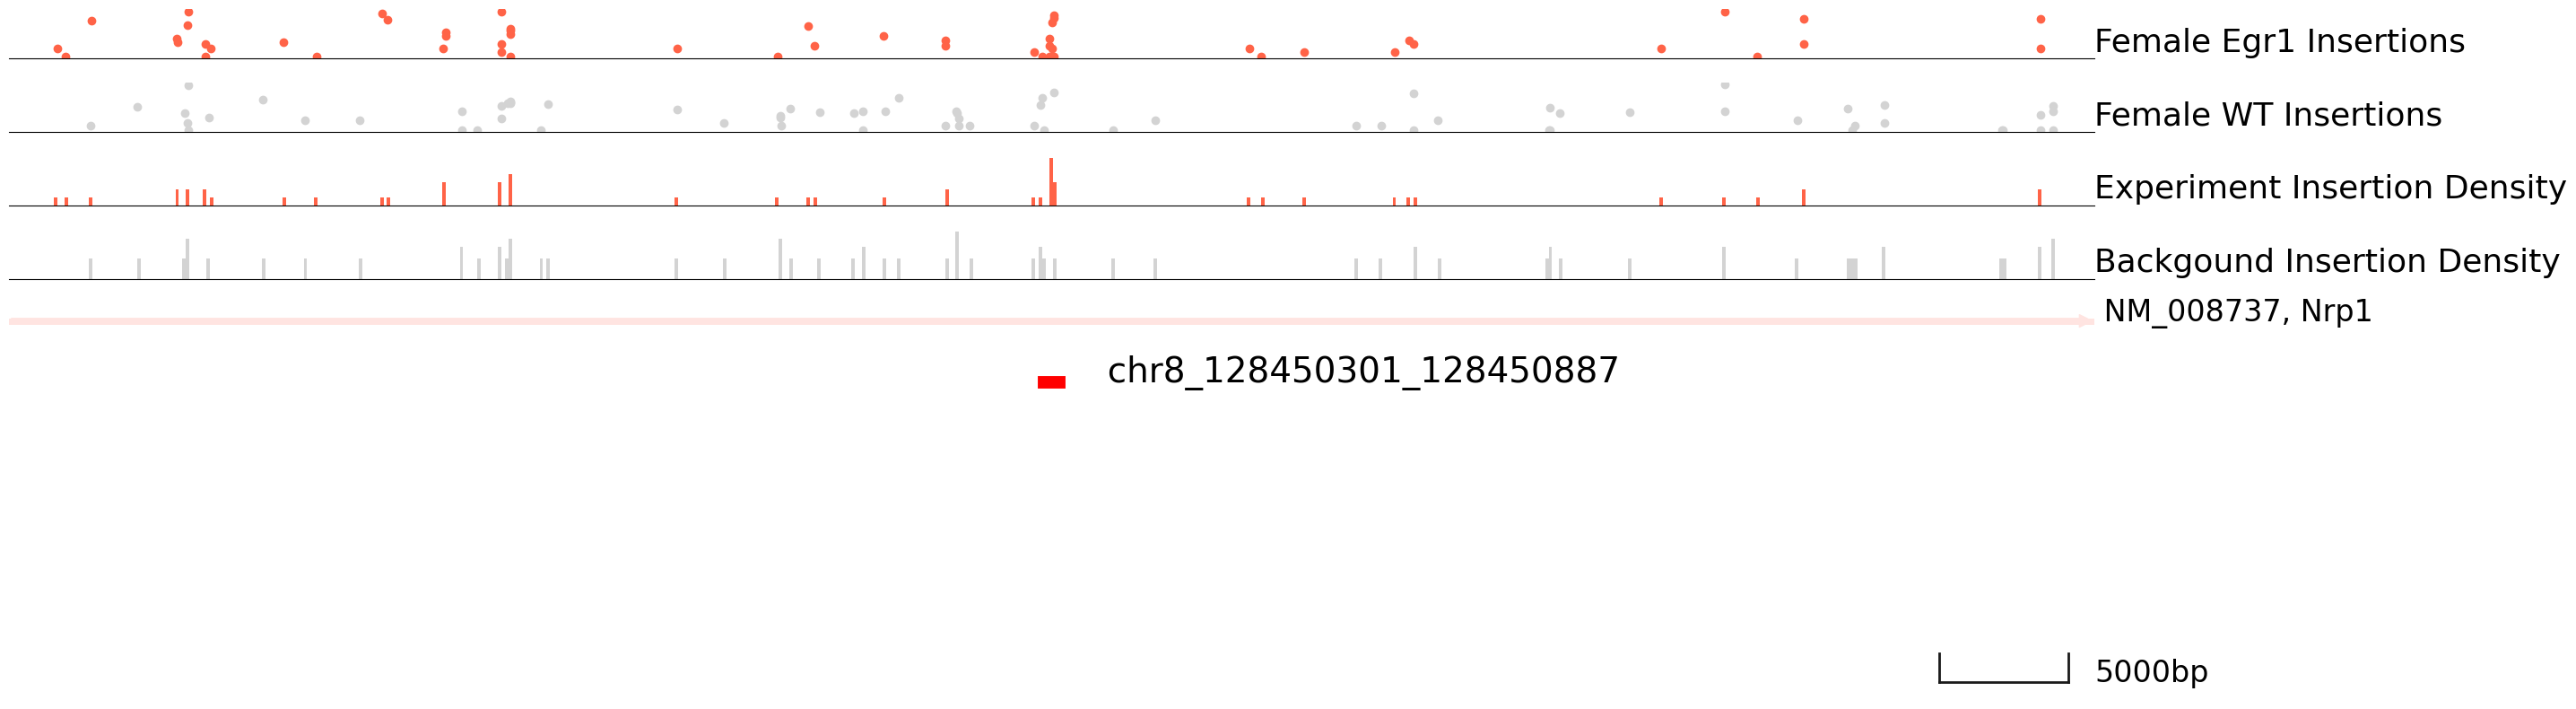

In [31]:
cc.pl.draw_area("chr8",128450301,128450887,40000, peak_annotation_combined, Male_Egr1, "mm10", Male_WT, font_size=2,
                name = "Male_Egr1", key = "Index", insertionkey = "group", figsize = (30,10), plotsize = [1,1,4],
                name_insertion1 = 'Male Egr1 Insertions', 
                name_insertion2 = 'Male WT Insertions', 
                peak_line = 3, bins = 600, example_length = 5000, color = "blue")#, title = "Male Egr1", save = 'Male_Egr1_WT_tracks_Zic4.pdf')
cc.pl.draw_area("chr8",128450301,128450887,40000, peak_annotation_combined, Female_Egr1, "mm10", Female_WT, font_size=2,
                name = "Female_Egr1", key = "Index", insertionkey = "group", figsize = (30,10), plotsize = [1,1,4],
                name_insertion1 = 'Female Egr1 Insertions', 
                name_insertion2 = 'Female WT Insertions', 
                peak_line = 3, bins = 600, example_length = 5000)#, title = "Female Egr1", save = 'Female_Egr1_WT_tracks_Zic4.pdf')


# What if I plot it with the male vs female and vice-versa way?

In [10]:
# 1) Get Nearest or 2nd Nearest CC peaks. (So both, but only keep unique genes in the list).

# Read in bed file so I don't have to rerun the code above everytime I open jupyterlab noteboook.
import pandas as pd
# Read BED file into a DataFrame
bed_file = "Egr1CC_peak_MaleEgr1_VS_FemaleEgr1_MACC2_YchromFiltered_window300_bg005_p05_TTAAp001_052125.bed"
peak_data_MaleVsFemale = pd.read_csv(bed_file, sep='\t', header=None)
# Add column names (optional)
peak_data_MaleVsFemale.columns = ['Chr', 'Start', 'End', 'Center', 'Experiment Insertions', 'Background insertions', 'Reference Insertions', 'pvalue Reference', 'pvalue Background', 'Fraction Experiment', 'TPH Experiment', 'Fraction background', 'TPH background', 'TPH background subtracted', 'pvalue_adj Reference']
#print(peak_data_Male.head())
len(peak_data_MaleVsFemale)

# Read in bed file so I don't have to rerun the code above everytime I open jupyterlab noteboook.
import pandas as pd
# Read BED file into a DataFrame
bed_file = "Egr1CC_peak_FemaleEgr1_VS_MaleEgr1_MACC2_YchromFiltered_window300_bg005_p05_TTAAp001_052125.bed"
peak_data_FemaleVsMale = pd.read_csv(bed_file, sep='\t', header=None)
# Add column names (optional)
peak_data_FemaleVsMale.columns = ['Chr', 'Start', 'End', 'Center', 'Experiment Insertions', 'Background insertions', 'Reference Insertions', 'pvalue Reference', 'pvalue Background', 'Fraction Experiment', 'TPH Experiment', 'Fraction background', 'TPH background', 'TPH background subtracted', 'pvalue_adj Reference']
#print(peak_data_Male.head())
len(peak_data_FemaleVsMale)

# Annotate
peak_annotation_MaleVsFemale = cc.pp.annotation(peak_data_MaleVsFemale, reference = "mm10", bedtools_path = '/ref/rmlab/software/pycallingcards/bin')
peak_annotation_MaleVsFemale = cc.pp.combine_annotation(peak_data_MaleVsFemale, peak_annotation_MaleVsFemale)
peak_annotation_MaleVsFemale
# Keep only peaks whose nearest gene is within 20kb
peak_annotation_MaleVsFemale = peak_annotation_MaleVsFemale[peak_annotation_MaleVsFemale['Distance1'].abs() <= 20000].reset_index(drop=True)
#peak_annotation_Male_100000 = peak_annotation_Male[peak_annotation_Male['Distance1'].abs() <= 100000].reset_index(drop=True)
peak_annotation_MaleVsFemale.to_csv("MaleVsFemale_Egr1CC_peaks_20kbThreshhold_091125_111225.txt", sep="\t", index=False, header=True)
#peak_annotation_Male_100000.to_csv("Male_Egr1CC_peaks_100kbThreshhold_090825.txt", sep="\t", index=False, header=True)

peak_annotation_FemaleVsMale = cc.pp.annotation(peak_data_FemaleVsMale, reference = "mm10", bedtools_path = '/ref/rmlab/software/pycallingcards/bin')
peak_annotation_FemaleVsMale = cc.pp.combine_annotation(peak_data_FemaleVsMale, peak_annotation_FemaleVsMale)
peak_annotation_FemaleVsMale
peak_annotation_FemaleVsMale = peak_annotation_FemaleVsMale[peak_annotation_FemaleVsMale['Distance1'].abs() <= 20000].reset_index(drop=True)
#peak_annotation_Female_100000 = peak_annotation_Female[peak_annotation_Female['Distance1'].abs() <= 100000].reset_index(drop=True)
peak_annotation_FemaleVsMale.to_csv("FemaleVsMale_Egr1CC_peaks_20kbThreshhold_091125_111225.txt", sep="\t", index=False, header=True)
#peak_annotation_Female_100000.to_csv("Female_Egr1CC_peaks_100kbThreshhold_090825.txt", sep="\t", index=False, header=True)



In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.
In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.


In [18]:
peak_annotation_MaleVsFemale

,Chr,Start,End,Center,Experiment Insertions,Background insertions,Reference Insertions,pvalue Reference,pvalue Background,Fraction Experiment,...,TPH background subtracted,pvalue_adj Reference,Nearest Refseq1,Gene Name1,Direction1,Distance1,Nearest Refseq2,Gene Name2,Direction2,Distance2
0,chr1,4807326,4807729,4807526.0,19,5,2,0.000000e+00,8.411021e-04,0.000009,...,485.548464,0.000000e+00,NM_008866,Lypla1,+,164,NR_033530,Mrpl15,-,-21601
1,chr1,6277966,6278384,6278181.0,8,3,2,6.965725e-10,4.683232e-03,0.000004,...,128.502329,6.691441e-07,NM_009826,Rb1cc1,+,-1863,NM_001195732,Alkal1,+,80947
2,chr1,6279125,6279578,6279375.0,24,6,4,0.000000e+00,3.356168e-08,0.000011,...,640.126421,0.000000e+00,NM_009826,Rb1cc1,+,-3022,NM_001195732,Alkal1,+,79753
3,chr1,6288214,6288617,6288414.0,5,0,1,3.317367e-07,1.274899e-09,0.000002,...,239.451101,2.330173e-04,NM_009826,Rb1cc1,+,-12111,NM_001195732,Alkal1,+,70714
4,chr1,7089743,7090926,7090380.0,112,27,13,0.000000e+00,3.106237e-11,0.000054,...,3072.129775,0.000000e+00,NM_183028,Pcmtd1,+,0,NM_001244693,St18,+,-228804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6323,chrX,167952120,167952753,167952435.0,6,2,7,2.438694e-09,2.477608e-03,0.000003,...,117.595033,2.215896e-06,NM_001290427,Frmpd4,-,0,NM_001290428,Frmpd4,-,-97044
6324,chrX,169685667,169686070,169685867.0,11,0,3,1.598721e-14,1.818001e-11,0.000005,...,526.792423,2.269444e-11,NM_010797,Mid1,+,0,NR_003635,4933400A11Rik,-,90308
6325,chrX,169810946,169811409,169811190.0,7,0,5,3.536660e-07,7.667802e-08,0.000003,...,335.231542,2.475660e-04,NM_010797,Mid1,+,0,NM_001290504,Mid1,+,16750
6326,chrY,1286497,1287017,1286724.0,23,0,6,0.000000e+00,4.678840e-03,0.000011,...,1101.475067,0.000000e+00,NM_012008,Ddx3y,-,0,NM_148943,Usp9y,-,11944


In [15]:
peak_annotation_FemaleVsMale

,Chr,Start,End,Center,Experiment Insertions,Background insertions,Reference Insertions,pvalue Reference,pvalue Background,Fraction Experiment,...,TPH background subtracted,pvalue_adj Reference,Nearest Refseq1,Gene Name1,Direction1,Distance1,Nearest Refseq2,Gene Name2,Direction2,Distance2
0,chr1,4849365,4849868,4849639.0,6,4,5,1.590951e-07,3.122143e-02,0.000005,...,317.677985,7.468908e-05,NM_008866,Lypla1,+,-2631,NM_011541,Tcea1,+,7826
1,chr1,4858460,4859513,4858781.0,62,49,11,0.000000e+00,1.361602e-05,0.000053,...,2915.514156,0.000000e+00,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-11726
2,chr1,4859557,4860097,4859828.0,12,1,8,3.919087e-14,5.155099e-12,0.000010,...,970.587512,3.843744e-11,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-12823
3,chr1,6274010,6274413,6274210.0,5,0,1,3.218919e-07,1.274899e-09,0.000004,...,424.365722,1.441256e-04,NM_009826,Rb1cc1,+,0,NM_001195732,Alkal1,+,84918
4,chr1,6282928,6283331,6283128.0,23,16,3,0.000000e+00,3.677815e-02,0.000020,...,1185.838796,0.000000e+00,NM_009826,Rb1cc1,+,-6825,NM_001195732,Alkal1,+,76000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10626,chrX,169861134,169861537,169861334.0,8,2,4,3.064298e-10,1.481614e-05,0.000007,...,583.204714,2.062468e-07,NM_010797,Mid1,+,0,NM_001290506,Mid1,+,18082
10627,chrX,169882972,169883467,169883172.0,10,7,8,1.646687e-10,8.002139e-03,0.000008,...,513.499902,1.143971e-07,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,91576
10628,chrX,169884037,169884863,169884511.0,15,10,12,9.325873e-15,1.263577e-03,0.000013,...,794.194962,9.671389e-12,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,90180
10629,chrX,169898268,169898791,169898468.0,10,4,9,4.302897e-10,1.057193e-04,0.000008,...,657.170562,2.848854e-07,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,76252


In [19]:
# genes to search for
genes_of_interest = ['Nrp1', 'Hmox1', 'Mast4', 'Ptk2b']

# rows where Gene Name1 contains any of those genes
matches = peak_annotation_MaleVsFemale[peak_annotation_MaleVsFemale['Gene Name1'].isin(genes_of_interest)]

print(matches)

        Chr      Start        End       Center  Experiment Insertions  \
1679  chr13  102897977  102898500  102898297.0                     15   
1680  chr13  102914399  102914817  102914599.0                     13   
1892  chr14   66257838   66258386   66258096.0                     38   
1893  chr14   66258319   66258908   66258705.0                     18   
1894  chr14   66259072   66259507   66259272.0                     18   
5627   chr8   75083077   75083498   75083295.0                      7   

      Background insertions  Reference Insertions  pvalue Reference  \
1679                      2                     3      1.221245e-15   
1680                      1                     3      4.596323e-13   
1892                      9                     6      0.000000e+00   
1893                      3                     7      0.000000e+00   
1894                      2                     3      0.000000e+00   
5627                      1                     2      7.58957

In [20]:
# genes to search for
genes_of_interest = ['Nrp1', 'Hmox1', 'Mast4', 'Ptk2b']

# rows where Gene Name1 contains any of those genes
matches = peak_annotation_FemaleVsMale[peak_annotation_FemaleVsMale['Gene Name1'].isin(genes_of_interest)]

print(matches)

        Chr      Start        End       Center  Experiment Insertions  \
2750  chr13  102865958  102866627  102866253.0                      7   
2751  chr13  102899110  102899513  102899310.0                     10   
2752  chr13  102976048  102976567  102976364.0                      7   
2753  chr13  103077425  103078275  103078017.0                     16   
2754  chr13  103097019  103097540  103097219.0                      5   
2755  chr13  103102595  103102998  103102795.0                      7   
9553   chr8   75084331   75084865   75084624.0                     12   
9554   chr8   75087726   75088252   75087926.0                     11   
9555   chr8   75094600   75095342   75094974.0                     12   
9817   chr8  128361140  128361732  128361529.0                     10   

      Background insertions  Reference Insertions  pvalue Reference  \
2750                      3                     5      8.792396e-07   
2751                      7                     1     

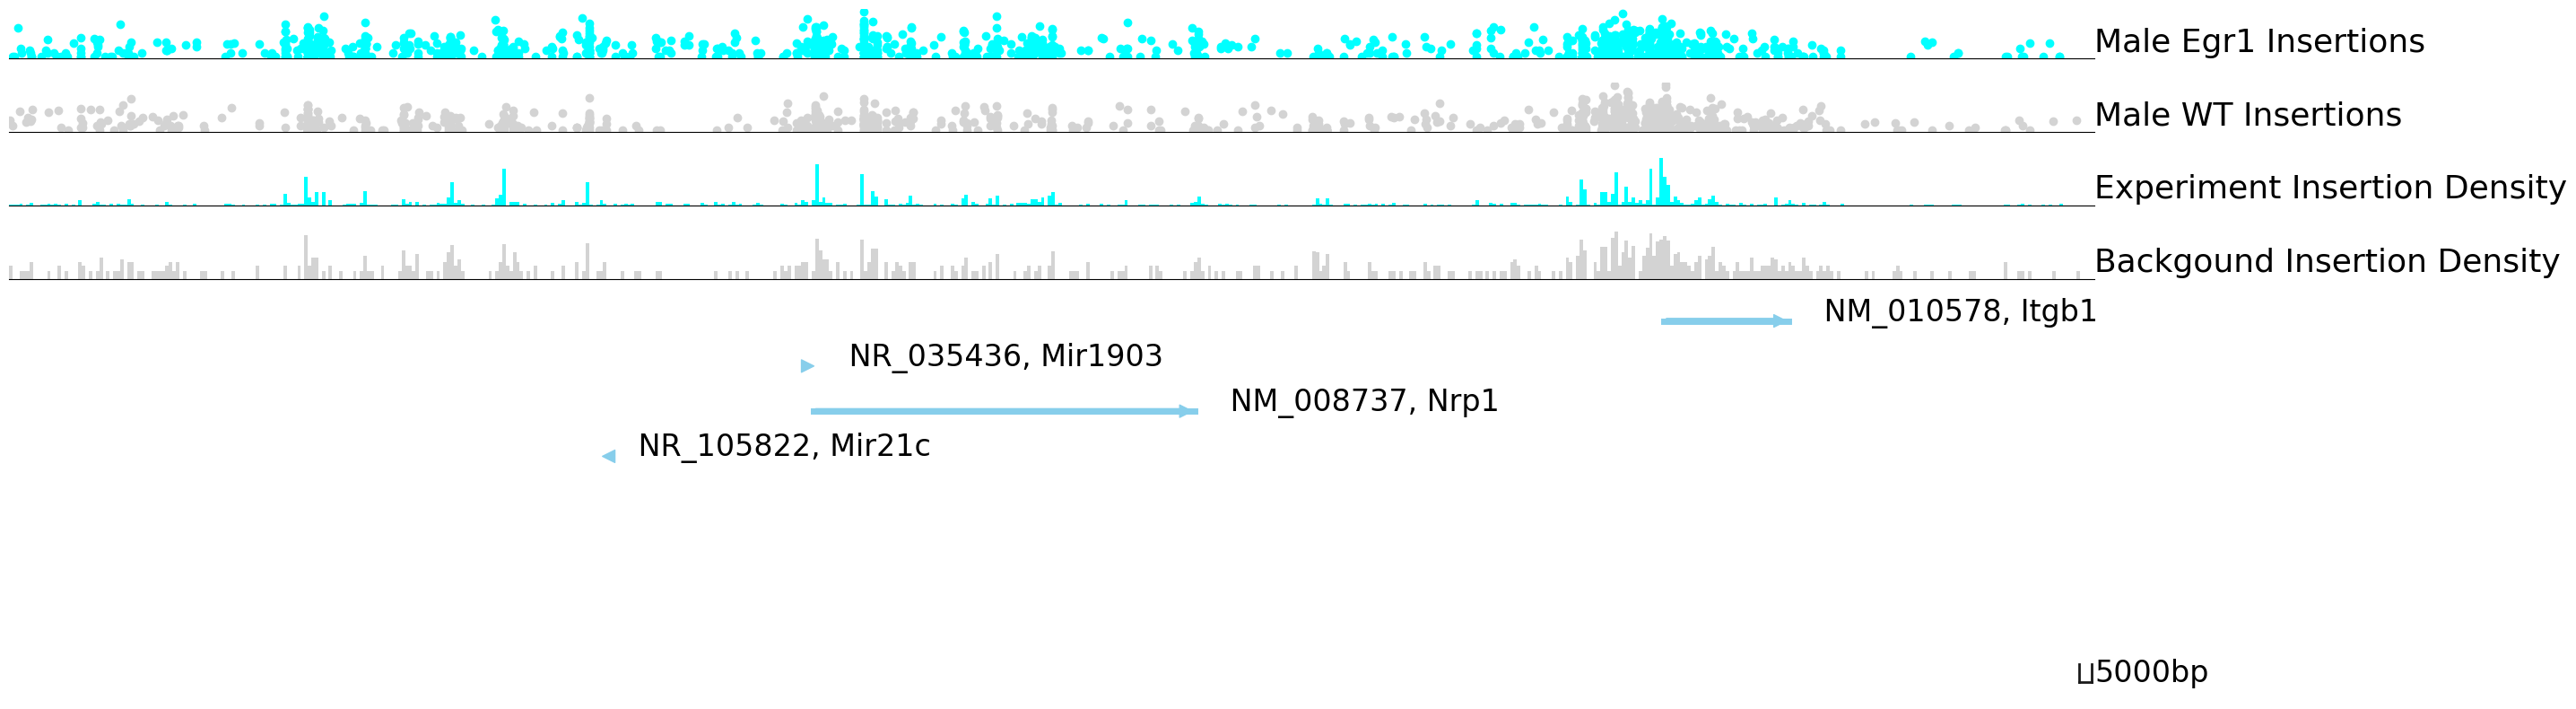

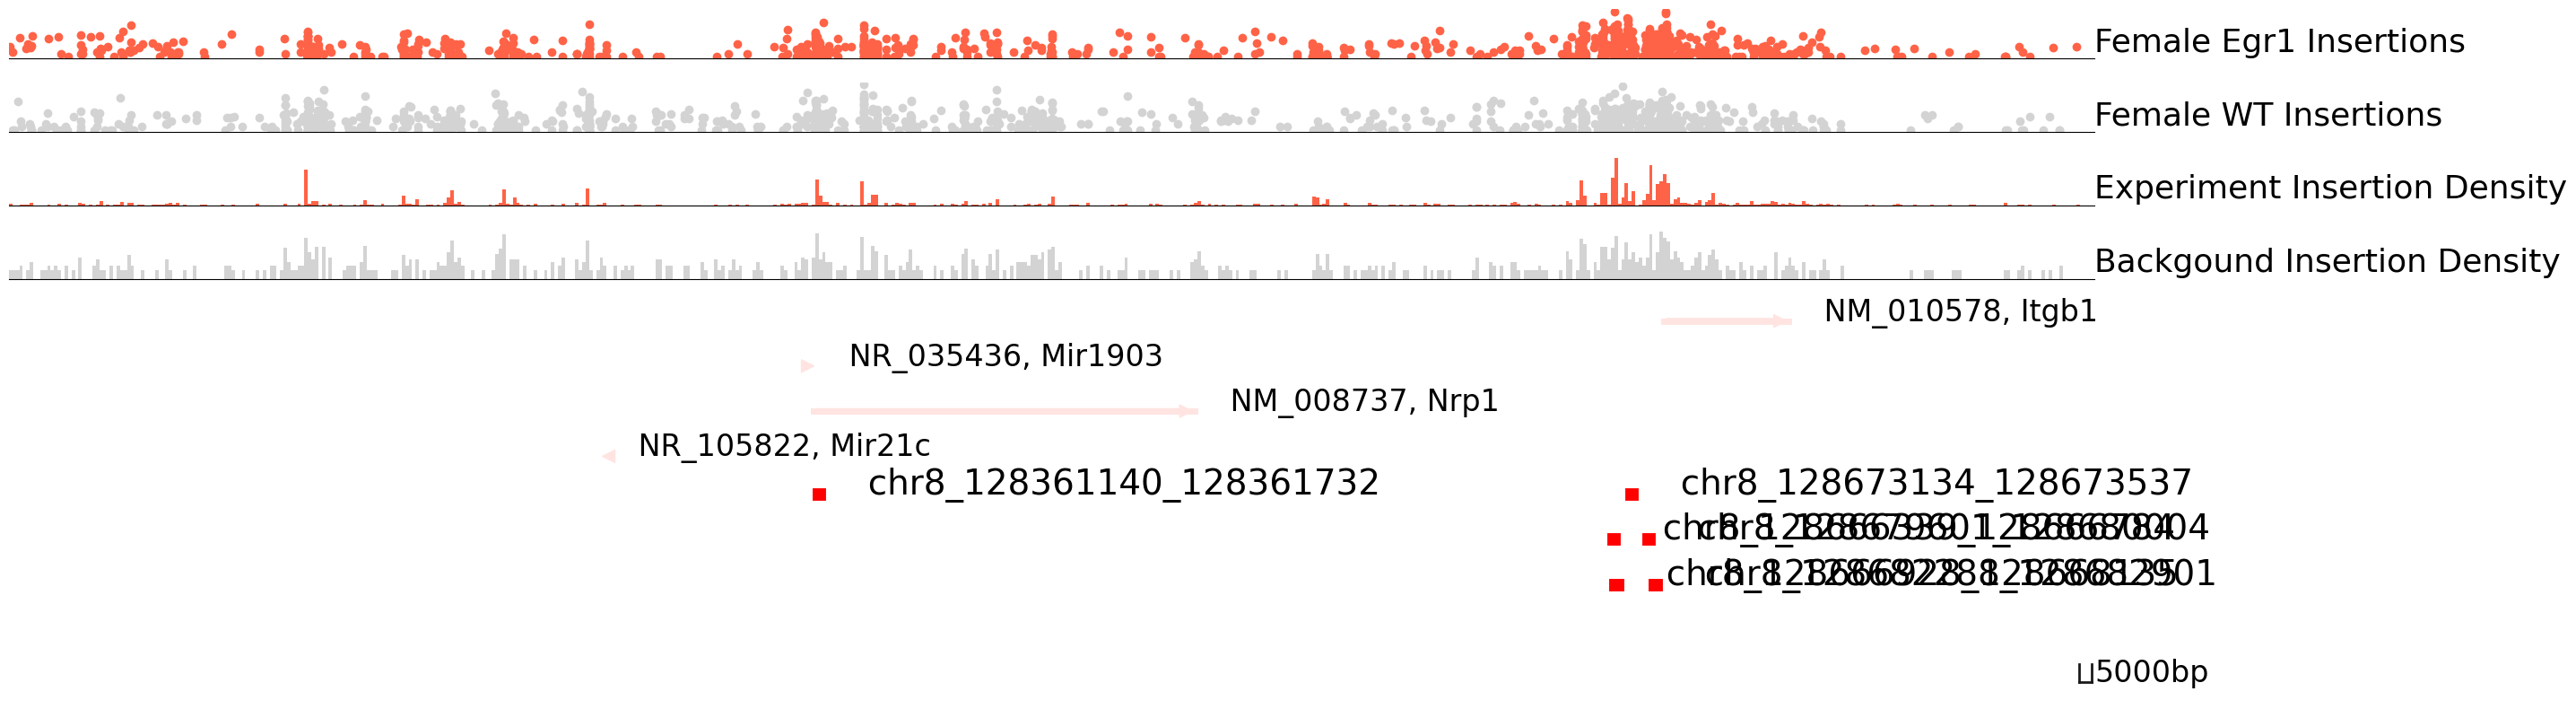

In [43]:
cc.pl.draw_area("chr8",128450301,128450887,400000, peak_annotation_MaleVsFemale, Male_Egr1, "mm10", Female_Egr1, font_size=2,
                name = "Male_Egr1", key = "Index", insertionkey = "group", figsize = (30,10), plotsize = [1,1,4],
                name_insertion1 = 'Male Egr1 Insertions', 
                name_insertion2 = 'Male WT Insertions', 
                peak_line = 3, bins = 600, example_length = 5000, color = "blue")#, title = "Male Egr1", save = 'Male_Egr1_WT_tracks_Zic4.pdf')
cc.pl.draw_area("chr8",128450301,128450887,400000, peak_annotation_FemaleVsMale, Female_Egr1, "mm10", Male_Egr1, font_size=2,
                name = "Female_Egr1", key = "Index", insertionkey = "group", figsize = (30,10), plotsize = [1,1,4],
                name_insertion1 = 'Female Egr1 Insertions', 
                name_insertion2 = 'Female WT Insertions', 
                peak_line = 3, bins = 600, example_length = 5000)#, title = "Female Egr1", save = 'Female_Egr1_WT_tracks_Zic4.pdf')


# Find genes bound in both, but repressed in Females so I can run homer on them. Question to answer here: Is Egr1 binding with another TF to inhibit transcription in females? 

In [50]:
import pandas as pd

# --- repressed genes from female Egr1-KD RNAseq ------------------------------
KD_F_1 = pd.read_csv(
    '/lts/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/'
    'pycallingcards/R_work/Female_Egr1KDg3_vs_Female_NoTreatg1_DE_vst_filtered_091625.txt',
    sep='\t')
print("DE file columns:", KD_F_1.columns.tolist())   # <-- find the gene-symbol column

repressed = KD_F_1[(KD_F_1['log2FoldChange'] >= 0.5) & (KD_F_1['pvalue'] <= 0.05)]
print(f"Repressed female genes: {len(repressed)}")

GENE_COL = 'SYMBOL'                                     # <-- set from the print above
repressed_genes = set(repressed[GENE_COL].astype(str))
# if gene symbols are the row index instead of a column:
#   repressed_genes = set(repressed.index.astype(str))

# --- CC peaks whose nearest gene (within 20 kb) is a repressed gene ----------
sel = peak_annotation_combined[    (peak_annotation_combined['Gene Name1'].astype(str).isin(repressed_genes))
].copy()
print(f"CC peaks near repressed female genes: {len(sel)}")

# --- write a HOMER-format 6-column BED  (chr, start, end, name, score, strand)
homer_bed = sel[['Chr', 'Start', 'End']].copy()
homer_bed['Start']  = homer_bed['Start'].astype(int)
homer_bed['End']    = homer_bed['End'].astype(int)
homer_bed['name']   = [f'peak_{i}' for i in range(len(homer_bed))]
homer_bed['score']  = 0
homer_bed['strand'] = '+'

OUT = ("/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/testing_CC_forPaper/"
       "Female_repressed_Egr1CC_peaks.bed")
homer_bed.to_csv(OUT, sep='\t', index=False, header=False)
print(f"Saved {len(homer_bed)} peaks -> {OUT}")

DE file columns: ['Unnamed: 0', 'baseMean', 'log2FoldChange', 'lfcSE', 'stat', 'pvalue', 'padj', 'SYMBOL']
Repressed female genes: 540
CC peaks near repressed female genes: 252
Saved 252 peaks -> /scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/testing_CC_forPaper/Female_repressed_Egr1CC_peaks.bed


# Now try to make heatmap from these combined peaks - the shared and biased peaks with logfc of 1

In [51]:
# =============================================================================
# 7. SAVE PLAIN BED FILES FOR deepTools (computeMatrix / plotHeatmap)
# =============================================================================
def names_to_bed(de_df):
    bed = de_df['names'].str.split('_', expand=True)
    bed.columns = ['Chr', 'Start', 'End']
    bed['Start'] = bed['Start'].astype(int)
    bed['End']   = bed['End'].astype(int)
    return bed

male_biased_bed   = names_to_bed(male_biased)
female_biased_bed = names_to_bed(female_biased)
shared_out        = shared_bed[['Chr', 'Start', 'End']].astype({'Start': int, 'End': int})

for df_, fn in [(shared_out,        'Egr1_shared_peaks_calledtogether_logfc1.bed'),
                (male_biased_bed,   'Egr1_male_biased_peaks_calledtogether_logfc1.bed'),
                (female_biased_bed, 'Egr1_female_biased_peaks_calledtogether_logfc1.bed')]:
    df_.sort_values(['Chr', 'Start']).to_csv(fn, sep='\t', index=False, header=False)
    print(f"  {fn}: {len(df_)} peaks")

  Egr1_shared_peaks_calledtogether_logfc1.bed: 8257 peaks
  Egr1_male_biased_peaks_calledtogether_logfc1.bed: 217 peaks
  Egr1_female_biased_peaks_calledtogether_logfc1.bed: 226 peaks


In [52]:
male_biased_bed

,Chr,Start,End
0,chr4,88956665,88957354
1,chr12,98572464,98573066
2,chr10,117150125,117150773
3,chr1,71111583,71112226
4,chr19,44263511,44264604
...,...,...,...
212,chr14,57316830,57317496
213,chr11,97817191,97817594
214,chr2,122349012,122349415
215,chr2,115859618,115860021


In [63]:
# =============================================================================
# 7. LABEL, COMBINE, OVERLAP WITH gRNA3-vs-Neg RNAseq  -- run as ONE cell
# =============================================================================

# --- 7a. label each peak set and combine -------------------------------------
female_annotated = female_annotated.assign(category='female_biased')
male_annotated   = male_annotated.assign(category='male_biased')
shared_annotated = shared_annotated.assign(category='shared')

combined = pd.concat([female_annotated, male_annotated, shared_annotated],
                     ignore_index=True)
combined.to_csv('Egr1_allpeaks_labeled_logfc1.csv', index=False)
print(f"Combined: {len(combined)} peaks "
      f"(female {len(female_annotated)}, male {len(male_annotated)}, shared {len(shared_annotated)})")

# --- 7b. load the two FULL RNAseq DE tables (explicit paths, no glob) --------
RNA_DIR = ("/lts/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/"
           "101524_Egr1CC_analysis/pycallingcards/R_work")
FEMALE_RNA = f"{RNA_DIR}/Female_Egr1KDg3_vs_Female_NoTreatg1_DE_vst_filtered_091625.txt"
MALE_RNA   = f"{RNA_DIR}/Male_Egr1KDg3_vs_Male_NoTreatg1_DE_vst_filtered_091625.txt"

rna_f = pd.read_csv(FEMALE_RNA, sep='\t')
rna_m = pd.read_csv(MALE_RNA,   sep='\t')
print(f"Female RNAseq: {len(rna_f)} genes | Male RNAseq: {len(rna_m)} genes")

GENE_COL_RNA  = 'SYMBOL'        # gene-symbol column in the RNAseq tables
GENE_COL_PEAK = 'Gene Name1'    # nearest-gene column in the annotated peaks

# --- 7c. merge RNAseq log2FC / pvalue onto each peak's nearest gene ----------
def rna_slim(rna, tag):
    out = rna[[GENE_COL_RNA, 'log2FoldChange', 'pvalue']].copy()
    out.columns = ['gene', f'log2FC_{tag}', f'pvalue_{tag}']
    return (out.dropna(subset=['gene'])
               .sort_values(f'pvalue_{tag}')
               .drop_duplicates('gene'))

combined = (combined
            .merge(rna_slim(rna_f, 'female_KD'), how='left',
                   left_on=GENE_COL_PEAK, right_on='gene').drop(columns='gene')
            .merge(rna_slim(rna_m, 'male_KD'), how='left',
                   left_on=GENE_COL_PEAK, right_on='gene').drop(columns='gene'))
print("matched to female RNAseq:", combined['log2FC_female_KD'].notna().sum(), "/", len(combined))
print("matched to male RNAseq:  ", combined['log2FC_male_KD'].notna().sum(), "/", len(combined))

# --- 7d. direction call per sex + "changing direction" flag ------------------
LFC_RNA, P_RNA = 0.5, 0.05

def direction(lfc, p):
    if pd.isna(lfc) or pd.isna(p) or p > P_RNA or abs(lfc) < LFC_RNA:
        return 'ns'
    return 'up' if lfc > 0 else 'down'

combined['dir_female_KD'] = [direction(l, p) for l, p in
                             zip(combined['log2FC_female_KD'], combined['pvalue_female_KD'])]
combined['dir_male_KD']   = [direction(l, p) for l, p in
                             zip(combined['log2FC_male_KD'], combined['pvalue_male_KD'])]

combined['opposite_direction'] = (
    combined['dir_female_KD'].isin(['up', 'down']) &
    combined['dir_male_KD'].isin(['up', 'down']) &
    (combined['dir_female_KD'] != combined['dir_male_KD']))

# --- 7e. save ----------------------------------------------------------------
combined.to_csv('Egr1_allpeaks_labeled_with_RNAseq_logfc1.csv', index=False)
opp = combined[combined['opposite_direction']]
opp.to_csv('Egr1_peaks_RNAseq_opposite_direction_logfc1.csv', index=False)

print(f"\nSaved master table: {len(combined)} peaks")
print(f"Nearest gene changes direction (male KD vs female KD): {len(opp)} peaks")
print(opp.groupby('category').size())

Combined: 7105 peaks (female 226, male 217, shared 6662)
Female RNAseq: 18180 genes | Male RNAseq: 18180 genes
matched to female RNAseq: 6232 / 7105
matched to male RNAseq:   6232 / 7105

Saved master table: 7105 peaks
Nearest gene changes direction (male KD vs female KD): 2 peaks
category
shared    2
dtype: int64
